## Zweck des Skripts

Dieses Skript dient der automatisierten Suche, Auswahl und Aufbereitung von Sentinel-2-Level-2A-Daten für eine beliebige Area of Interest (AOI). Ziel ist es, für jedes Untersuchungsjahr innerhalb eines festgelegten saisonalen Zeitfensters eine geeignete, möglichst wolkenarme Szene zu identifizieren und daraus standardisierte Composites (NDVI und NBR) für die weitere Analyse zu erstellen.

Die wichtigsten Eingangsparameter wie AOI, Untersuchungsjahre, Untersuchungszeitraum, Wolkenfilter und verwendete Bänder können zu Beginn des Skripts angepasst werden. Dadurch ist der Workflow grundsätzlich auf beliebige AOIs übertragbar, sofern für den gewählten Zeitraum geeignete Sentinel-2-Daten verfügbar sind.

Die erstellten Outputs umfassen RGB-Composites zur visuellen Kontrolle sowie die spektralen Index-Composites NDVI und NBR. Diese dienen als Grundlage für die anschliessende Change Detection und Zeitreihenanalyse.

Das Skript ist auf einen zusammenhängenden Untersuchungszeitraum pro Jahr ausgelegt, z. B. Juni bis Juli. Für mehrere getrennte Zeitfenster innerhalb desselben Jahres müsste der Workflow entsprechend erweitert werden. Ebenso müsste der Code angepasst werden, sofern andere Composites (z.B. EVI) erstellt werden sollen.

## Workflow

Der Workflow beginnt mit der [Definition der zentralen Eingangsparameter](#sec-params). Dazu gehören die AOI, die Untersuchungsjahre, der saisonale Untersuchungszeitraum pro Jahr, die verwendeten Sentinel-2-Bänder sowie die Kriterien für die Szenenauswahl.

Anschliessend wird über den STAC-Katalog des `Microsoft Planetary Computers` nach Sentinel-2-Level-2A-Szenen gesucht. Im Kapitel [Passende Szenen via STAC suchen](#sec-stac) ist der Workflow detailliert beschrieben. Die gefundenen STAC-Items werden nach Aufnahmedatum gruppiert, da eine AOI je nach Lage durch mehrere Sentinel-2-Tiles abgedeckt werden kann. Für jedes Datum wird geprüft, ob die vorhandenen Tiles die AOI ausreichend abdecken. Nur Szenen mit ausreichender räumlicher Abdeckung werden weiterverwendet.

Für alle validen Szenen wird im Kapitel [Wolkenärmste Szene pro Jahr bestimmen](#sec-best_scene) der Wolkenanteil innerhalb der AOI anhand des SCL-Layers berechnet. Pro Untersuchungsjahr wird jene Szene ausgewählt, welche den geringsten Wolkenanteil aufweist. Diese Szenen bilden die Grundlage für die weitere Rasterverarbeitung.

Im nächsten Schritt (Kapitel [Preprocessing](#sec-prepro)) werden die ausgewählten Sentinel-2-Bänder und der SCL-Layer geladen, zu Mosaiken zusammengeführt, auf die AOI zugeschnitten und wolkenmaskiert. Die Verarbeitung läuft automatisiert über alle ausgewählten Untersuchungsjahre.

Abschliessend werden im Kapitel [Composites erstellen](#sec-composites) aus den aufbereiteten Rasterdaten RGB-Composites sowie spektrale Index-Composites wie NDVI und NBR erstellt. Die RGB-Composites dienen der visuellen Kontrolle, während NDVI und NBR als Grundlage für die anschliessende Change Detection und Zeitreihenanalyse verwendet werden.

Das Skript wird im Anschluss gewechselt, weil der API-Zugriff über einen Token gegeben ist, der zeitlich begrenzt ist. Um dies zu umgehen werden die Raster gespeichert und im Skript 3 neu geladen und weiterverarbeitet.

## Vorbereitung

### Libraries importieren

Zu Übersichtszwecken, und damit die Libraries nicht mehrfach geladen werden, sollen alle zu Beginn des Skripts aufgeführt und geladen werden.

In [2]:
# Standard library
import os
from collections import defaultdict

# STAC / Sentinel-2 data access
from pystac_client import Client
import planetary_computer as pc
import stackstac

# Data handling
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd

# Geometries
from shapely.geometry import shape
from shapely.ops import unary_union

# Raster processing
import rioxarray as rio
from rasterio.enums import Resampling

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium

### Fixe Parameter definieren

In [3]:
# Link zum STAC-Catalog 
catalog_link = "https://planetarycomputer.microsoft.com/api/stac/v1" 

# STAC-Kollektion spezifizieren 
platform = "sentinel-2-l2a" 

### Anpassbare Parameter definieren {#sec-params}

Wichtige Anmerkung: Die maximale Wolkenbedeckung wird hier **pro Tile** angegeben und soll locker gelassen werden. Die Auswahl der am wenigsten bewölkten Szene über AOI folgt später.

In [4]:
# hier die zu betrachtenden Jahre (Start- und Endjahr) spezifizieren
years = range(2021, 2025+1) # range() exkludiert letzten Wert --> +1

# hier den jeweiligen Zeitraum spezifizieren (-MM-DD)
range_start_date = "-07-01" 
range_end_date = "-07-31" 

# hier Cloud Cover (max) definieren (pro Tile nicht pro Szene)
cloud = 40 

# hier die für Composites benötigte Bänder spezifizieren 
bands = ["B02", "B03", "B04", "B08", "B12"] # Blue, Green, Red, NIR, SWIR 
scl = ["SCL"] # SCL für Wolkenmaskierung

# Für Plots: Name der AOI
aoi_name = "Karpaten"

#### Übersicht der Sentinel-2-Level-2a Kollektion

Die nachfolgende Tabelle zeigt eine Übersicht über die Produkte, die in der Sentinel-2-Level-2a Kollektion vorhanden sind. Die Bezeichnung der **Bänder**, welche unter `bands` spezifiziert wurden, müssen mit jener in der letzten Spalte `eo:bands` übereinstimmen.

In [5]:
cat = Client.open(catalog_link)
sentinel_collection = cat.get_collection(platform) # platform = "sentinel-2-l2a"

pd.DataFrame.from_dict(sentinel_collection.to_dict()["item_assets"], orient = "index")

,gsd,type,roles,title,eo:bands
AOT,10.0,image/tiff; application=geotiff; profile=cloud...,[data],Aerosol optical thickness (AOT),NaN
B01,60.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 1 - Coastal aerosol - 60m,"[{'name': 'B01', 'common_name': 'coastal', 'de..."
B02,10.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 2 - Blue - 10m,"[{'name': 'B02', 'common_name': 'blue', 'descr..."
B03,10.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 3 - Green - 10m,"[{'name': 'B03', 'common_name': 'green', 'desc..."
B04,10.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 4 - Red - 10m,"[{'name': 'B04', 'common_name': 'red', 'descri..."
B05,20.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 5 - Vegetation red edge 1 - 20m,"[{'name': 'B05', 'common_name': 'rededge', 'de..."
B06,20.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 6 - Vegetation red edge 2 - 20m,"[{'name': 'B06', 'common_name': 'rededge', 'de..."
B07,20.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 7 - Vegetation red edge 3 - 20m,"[{'name': 'B07', 'common_name': 'rededge', 'de..."
B08,10.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 8 - NIR - 10m,"[{'name': 'B08', 'common_name': 'nir', 'descri..."
B09,60.0,image/tiff; application=geotiff; profile=cloud...,[data],Band 9 - Water vapor - 60m,"[{'name': 'B09', 'description': 'Band 9 - Wate..."


### Polygon der AOI laden

Vorbereitetes Polygon in `.geojson`-Format importieren, welches in Skript ***`1_AOI_Polygon_vorbereiten`*** erstellt wurde.

In [6]:
# Polygon der AOI einlesen 
aoi = gpd.read_file("polygon_aoi.geojson")

In [7]:
# Zur Sicherheit CRS nochmals auf WGS84 setzen 
# (falls eine andere AOI verwendet wird und dieser
# Schritt vergessen wurde.
aoi = aoi.to_crs("EPSG:4326")

In [8]:
# Kontrolle CRS = WGS84 (EPSG:4326)--> wichtig für STAC-Suche
aoi.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
# Geometrie des Polygons ableiten für die STAC-Suche
aoi_geom = aoi.geometry.iloc[0]

In [10]:
# kurz Visualisieren zur Überprüfung

centroid = aoi_geom.centroid

m = folium.Map(location=[centroid.y, centroid.x], zoom_start=11)

folium.GeoJson(aoi_geom).add_to(m)

m

## Passende Szenen via STAC suchen {#sec-stac}

### Workflow 

Ziel: Für jeden Untersuchungszeitraum werden zunächst alle verfügbaren Sentinel-2-Szenen identifiziert, welche die definierte AOI räumlich nahezu vollständig abdecken und den definierten Suchkriterien (Zeitraum, maximale Wolkenbedeckung etc.) entsprechen. 

1. **Passende Tiles gemäss definierten Parametern suchen**
   - Abfrage von Daten über den STAC-Katalog
   - Filterung nach:
       - STAC-Kollektion (Sentinel-2 L2A) 
       - definiertem Zeitraum 
       - räumlichem Bezug zur AOI 
       - maximaler Wolkenbedeckung (pro Tile) 
   - *Ergebnis: Liste von STAC-Items (Tiles), welche die Suchkriterien erfüllen*
2. **Gruppierung nach Aufnahmedatum**
   - Gruppierung aller Tiles nach ihrem Aufnahmedatum
   - Tiles mit gleichem Datum werden zu potenzieller Szene zusammengefasst
   - *Ergebnis: Jede Datumsgruppe entspricht einer potenziellen Szene (bestehend aus einem oder mehreren Tiles)*
3. **Szenenbewertung und -filterung**
   - 3.1 Duplikate entfernen 
       - Pro Datumsgruppe Identifikation von Tiles mit identischer Geometrie
       - Beibehaltung eines repräsentativen Tiles pro Geometrie
   - 3.2 Sicherstellen, dass die ganze AOI abgedeckt wird
       - Umwandlung der Tile-Geometrien in Polygone
       - Bildung der geometrischen Vereinigung (union) aller Tiles pro Szene
       - Berechnung der Schnittfläche (intersection) mit der AOI
       - Bestimmung des Abdeckungsgrades
    - 3.3 Valide Szenen auswählen 
       - Nur Szenen mit ausreichender Abdeckung (z. B. ≥ 99 %) werden berücksichtigt
   - *Ergebnis: Liste gültiger Szenen, welche die AOI ausreichend abdecken & keine geometrischen Duplikate enthalten*
4. **Ausgabe der validierten Szenen pro Zeitraum**
   - *Ergebnis: Liste mit validen Szenen pro zu untersuchendem Zeitraum*

**Gesamtergebnis: vollständige Szenen (aus einem oder mehreren Tiles), die als Grundlage für die weitere Rasteranalyse dienen.**

### Funktionen für die STAC-Suche definieren

Siehe auch [Reading Data from the STAC API](https://github.com/microsoft/PlanetaryComputerExamples/blob/main/quickstarts/reading-stac.ipynb) und dieses [YouTube Video](https://www.youtube.com/watch?v=HHCsFHCQW5g)

**Die Funktionen werden jeweils mit einem Testjahr überprüft.**

In [11]:
year_test = years[1]
year_test

2022

#### 0. STAC-Katalog öffnen

In [12]:
catalog = Client.open(
    catalog_link, 
    modifier=pc.sign_inplace,  # damit werden die Resultate automatisch "signed" --> Zugriff
) 

#### 1. Passende Tiles suchen

Beschreibung der Funktion **`search_items`**:

In der Funktion `search_items` wird für ein gegebenes Jahr (`year`) im geöffneten STAC-Katalog (`catalog`) nach geeigneten Tiles gesucht. Zunächst wird auf Basis des übergebenen Jahres ein konkreter Suchzeitraum definiert und anschliessend eine STAC-Abfrage gemäss definierter Kriterien (Plattform, AOI etc.) durchgeführt. 

Die Suchergebnisse werden als Liste von STAC-Items (`items`) gespeichert. Jedes Item entspricht dabei einem einzelnen Tile inklusive zugehöriger Metadaten. 
Zur Kontrolle wird die Anzahl der gefundenen Tiles pro Jahr ausgegeben. Falls keine passenden Tiles gefunden werden, erfolgt eine entsprechende Hinweismeldung.

Die Funktion gibt schliesslich die Liste der gefundenen STAC-Items (`items`) zurück, welche als Grundlage für die weitere Verarbeitung dient.

In [13]:
def search_items(catalog, year):

    # Zeitraum definieren:
    start_date = f"{year}{range_start_date}"
    end_date = f"{year}{range_end_date}"

    # STAC-Abfrage
    search = catalog.search(
        collections = [platform],
        intersects = aoi_geom,                     # Tiles müssen meine AOI schneiden
        datetime = f"{start_date}/{end_date}",
        query = {"eo:cloud_cover": {"lt": cloud}},
    )

    items = list(search.items())

    # Ausgabetext definieren, wie viele Tiles im entsprechenden Zeitraum gefunden wurden

    if len(items) == 0:
        print(f"Step 1 | search items: ❌ no data, adjust defined parameters")
    else:
        print(f"Step 1 | search items: {len(items)} tiles found")
        
    return items

In [14]:
# überprüfen mit Testjahr
items_test = search_items(catalog, year_test)
items_test[:4]

Step 1 | search items: 23 tiles found


[<Item id=S2A_MSIL2A_20220729T090601_R050_T34TGR_20220730T133614>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20240714T220116>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20220728T185023>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T34TGR_20240714T220116>]

#### 2. Gruppierung nach Datum

Beschreibung der Funktion **`group_by_date`**:

Die Funktion `group_by_date` dient dazu, eine Liste von STAC-Items (Tiles) nach ihrem Aufnahmedatum zu strukturieren. Zunächst wird ein leeres Dictionary (`items_by_date`) vom Typ *defaultdict(list)* erstellt, welches automatisch für jedes neue Datum eine leere Liste anlegt.

Anschliessend wird über alle übergebenen STAC-Items (`item`) iteriert. Für jedes Item wird der Aufnahmezeitpunkt (*item.datetime*) extrahiert und in ein standardisiertes Datumsformat umgewandelt. Dabei wird der Zeitanteil entfernt, sodass nur das reine Datum (YYYY-MM-DD) erhalten bleibt. Die einzelnen Items werden anschliessend anhand dieses Datums gruppiert, indem sie der entsprechenden Liste im Dictionary zugeordnet werden. Das Ergebnis ist eine strukturierte Sammlung, in der alle Tiles mit gleichem Aufnahmedatum zusammengefasst sind und somit potenzielle Szenen bilden.

Die Funktion gibt das Dictionary `items_by_date` zurück, welches die Grundlage für die anschliessende Szenenbildung und Filterung darstellt.

In [15]:
def group_by_date(items):
    items_by_date = defaultdict(list)

    # Für jedes STAC-Item (Tile) Aufnahmedatum extrahieren 
    # und Items anschliessend nach Datum gruppieren
    for item in items:

        # item.datetime enthält den Aufnahmezeitpunkt als Timestamp ("2022-06-15T10:32:00Z")
        # pd.to_datetime konvertiert diesen String in ein pandas datetime-Objekt
        # .date() entfernt die Zeitkomponente, sodass nur das Datum (YYYY-MM-DD) übrig bleibt
        
        date = pd.to_datetime(item.datetime).date()

        # items_by_date ist ein defaultdict(list) 
        # --> für jedes neue Datum wird automatisch eine leere Liste erstellt
        # Anschliessend wird das aktuelle Item dieser Liste hinzugefügt.
        # Ergebnis: alle Satelliten-Tiles werden nach Aufnahmedatum gruppiert
        
        items_by_date[date].append(item)

    # Ausgabetext / Debug-Info definieren

    print(f"Step 2 | grouping by date: {len(items_by_date)} unique acquisition dates found")

    return items_by_date

In [16]:
# überprüfen mit Testjahr
items_by_date_test = group_by_date(items_test)
for date in items_by_date_test:
    print(date)

Step 2 | grouping by date: 8 unique acquisition dates found
2022-07-29
2022-07-27
2022-07-22
2022-07-19
2022-07-17
2022-07-14
2022-07-07
2022-07-02


#### 3. Szenenbewertung und -filterung

**3.1 Duplikate entfernen**

STAC liefert teilweise mehrere Items mit identischer räumlicher Ausdehnung (z. B. aufgrund unterschiedlicher Processing-Level oder redundanter Produktvarianten). Diese Funktion dient dazu, solche Duplikate innerhalb einer Szene zu entfernen, sodass pro geometrischer Ausdehnung nur ein repräsentatives Item erhalten bleibt.

Beschreibung der Funktion **`remove_duplicates`**:

In dieser Funktion wird über alle Items einer Datumsgruppe iteriert. Für jedes Item wird die geometrische Ausdehnung extrahiert und in eine eindeutige Zeichenkette (WKT-Format) umgewandelt. Diese geometrische Signatur dient als eindeutiger Identifikator.

Ein Set (`seen`) wird verwendet, um bereits vorkommende Geometrien zu speichern. Falls eine Geometrie bereits enthalten ist, wird das entsprechende Item übersprungen. Andernfalls wird die Geometrie zum Set hinzugefügt und das Item in die Liste der eindeutigen Elemente aufgenommen.

Das Ergebnis ist eine bereinigte Liste von STAC-Items (`unique_group`), in der jede räumliche Ausdehnung innerhalb einer Szene nur einmal vertreten ist. Die Variable `group` wird im Hauptloop beim Iterieren über das Dictionary `items_by_date` zugewiesen und repräsentiert jeweils die Liste der STAC-Items, die einem gemeinsamen Aufnahmedatum zugeordnet sind.

In [17]:
def remove_duplicates(group):
    seen = set()
    unique_group = []                              # Leere Liste für Output erstellen

    for item in group:
        geom_key = shape(item.geometry).wkt        # eindeutige geometrische Signatur

        if geom_key in seen:
            continue

        seen.add(geom_key)
        unique_group.append(item)

    return unique_group

In [18]:
# überprüfen mit Testjahr & Testgruppe

# Eine Datumgruppe vor Duplikatentfernung auswählen zum Vergleich
date_example = list(items_by_date_test.keys())[1]
group_example = items_by_date_test[date_example]
group_example

[<Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20240714T220116>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20220728T185023>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T34TGR_20240714T220116>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T34TGR_20220728T192839>]

In [19]:
# Eine Datumgruppe nach Duplikatentfernung auswählen
clean_group = remove_duplicates(group_example)
clean_group

[<Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20240714T220116>,
 <Item id=S2B_MSIL2A_20220727T091559_R093_T34TGR_20240714T220116>]

In [20]:
# --> geometrische Duplikate wurden entfernt (von 4 auf 2 Tiles)

**3.2 Abdeckung der AOI prüfen**

Hier wird geprüft, ob die Tiles (`item`) in den jeweiligen Datumsgruppen die gesamte AOI überdecken (keine Lücken).

Beschreibung der Funktion **`calculate_coverage`**:

In dieser Funktion wird die räumliche Abdeckung der AOI durch die zu einer Szene gehörenden STAC-Items berechnet. Als Eingabe dient die von Duplikaten bereinigte Liste `unique_group`, welche eine Liste von STAC-Items repräsentiert, die alle demselben Aufnahmedatum zugeordnet sind. Zusätzlich wird die AOI-Geometrie (`aoi_geom`) übergeben.

Zunächst wird für jedes Item (`item`) in der Gruppe (`unique_group`) die geometrische Ausdehnung extrahiert und in eine Liste von Shapely-Polygonen (`footprints`) umgewandelt. Anschliessend werden alle Polygone mittels geometrischer Vereinigung (`unary_union`) zu einer Gesamtgeometrie (`union`) zusammengeführt, welche die gesamte räumliche Abdeckung aller Tiles dieser Szene repräsentiert.

Zuletzt wird das Flächenverhältnis der Schnittmenge (`coverage`) zwischen der Gesamtgeometrie und der AOI berechnet. Das Ergebnis ist ein Wert zwischen 0 und 1, wobei 1 einer vollständigen Abdeckung der AOI entspricht.

In [21]:
def calculate_coverage(unique_group, aoi_geom):

    # Für jedes Item (Tile) in der Gruppe wird die Geometrie in ein Shapely-Polygon umgewandelt.
    # Ergebnis: Liste von Polygonen, die die räumliche Ausdehnung der einzelnen Tiles darstellen
    footprints = [shape(item.geometry) for item in unique_group]

    # Vereint alle Tile-Polygone zu einer einzigen Gesamtfläche (Union).
    # Dadurch entsteht die gesamte von allen Tiles gemeinsam abgedeckte Fläche dieses Datums.
    union = unary_union(footprints)

    # Berechung der Abdeckung meiner AOI durch die Tiles 
    coverage = union.intersection(aoi_geom).area / aoi_geom.area

    return coverage

In [22]:
# überprüfen mit Testjahr 
coverage_by_date = {}

for date, group in items_by_date_test.items():
    
    # Duplikate entfernen
    unique_group = remove_duplicates(group)
    
    # Coverage berechnen
    coverage = calculate_coverage(unique_group, aoi_geom)
    
    coverage_by_date[date] = coverage

In [23]:
coverage_by_date

{datetime.date(2022, 7, 29): 0.05769072123107963,
 datetime.date(2022, 7, 27): 0.9999999999999987,
 datetime.date(2022, 7, 22): 0.9999999999999987,
 datetime.date(2022, 7, 19): 0.9999999999999987,
 datetime.date(2022, 7, 17): 0.9999999999999987,
 datetime.date(2022, 7, 14): 0.9999999999999987,
 datetime.date(2022, 7, 7): 0.05769075272615751,
 datetime.date(2022, 7, 2): 0.9999999999999987}

**3.3 Valide Szenen speichern**

In diesem Schritt werden aus den nach Aufnahmedatum gruppierten und bereits bereinigten STAC-Items nur jene Szenen ausgewählt, welche eine nahezu vollständige räumliche Abdeckung der definierten Area of Interest (AOI) aufweisen.

Beschreibung der Funktion **`build_valid_scenes`**:

In dieser Funktion wird über alle im Dictionary `items_by_date` enthaltenen Datumsgruppen iteriert.

Für jede Datumsgruppe wird zunächst die Funktion `remove_duplicates` angewendet, um redundante geometrische Ausdehnungen innerhalb der Szene zu entfernen. Die daraus resultierende bereinigte Liste (`unique_group`) wird anschliessend an die Funktion `calculate_coverage` übergeben, um den räumlichen Abdeckungsgrad der AOI durch die jeweiligen Satelliten-Tiles zu bestimmen. Nur Szenen mit einer Abdeckung von mindestens 0.99 (99%) werden als vollständig betrachtet und in die Ergebnisliste aufgenommen.

Für jede gültige Szene wird ein Dictionary erstellt und der Liste `valid_scenes` hinzugefügt.

Die Funktion gibt abschliessend eine Liste aller gültigen Szenen zurück, welche sowohl räumlich konsistent als auch nahezu vollständig die definierte AOI abdecken und somit für weiterführende Analysen geeignet sind.

In [24]:
def build_valid_scenes(items_by_date, aoi_geom, year):

    valid_scenes = []

    for date, group in items_by_date.items():

        unique_group = remove_duplicates(group)
        coverage = calculate_coverage(unique_group, aoi_geom)

        if coverage < 0.99:
            continue

        valid_scenes.append({
            "year": year,
            "date": date,
            "items": unique_group,
            "coverage": coverage,
            "n_tiles": len(unique_group)
        })

    return valid_scenes

In [25]:
scenes_test = build_valid_scenes(items_by_date_test, aoi_geom, year_test)
scenes_test[:3]

[{'year': 2022,
  'date': datetime.date(2022, 7, 27),
  'items': [<Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20240714T220116>,
   <Item id=S2B_MSIL2A_20220727T091559_R093_T34TGR_20240714T220116>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2022,
  'date': datetime.date(2022, 7, 22),
  'items': [<Item id=S2A_MSIL2A_20220722T092041_R093_T35TLL_20240711T113555>,
   <Item id=S2A_MSIL2A_20220722T092041_R093_T34TGR_20240711T113555>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2022,
  'date': datetime.date(2022, 7, 19),
  'items': [<Item id=S2A_MSIL2A_20220719T090611_R050_T35TLL_20240715T222928>,
   <Item id=S2A_MSIL2A_20220719T090611_R050_T35TLL_20220719T222812>,
   <Item id=S2A_MSIL2A_20220719T090611_R050_T34TGR_20240715T222928>,
   <Item id=S2A_MSIL2A_20220719T090611_R050_T34TGR_20220719T225317>],
  'coverage': 0.9999999999999987,
  'n_tiles': 4}]

#### 4. Validierte Szenen bestätigen und ausgeben

Beschreibung der Funktion **`get_valid_scenes`**:

In dieser Funktion wird die zuvor erzeugte Liste gültiger Szenen (`valid_scenes`) für ein gegebenes Jahr (`year`) geprüft und für die weitere Verarbeitung zurückgegeben.

Zunächst wird geprüft, ob überhaupt gültige Szenen vorhanden sind. Falls die Liste leer ist, bedeutet dies, dass für das betrachtete Jahr keine Szene existiert, welche die definierten Kriterien (insbesondere eine ausreichende AOI-Abdeckung) erfüllt. In diesem Fall wird eine entsprechende Meldung ausgegeben.

Sind gültige Szenen vorhanden, werden diese nicht weiter reduziert oder priorisiert, sondern vollständig beibehalten. Die Auswahl einer einzelnen „besten“ Szene erfolgt bewusst nicht in diesem Schritt, da die endgültige Bewertung (anhand von Wolkenbedeckung aus SCL-Daten) erst in einem späteren Verarbeitungsschritt stattfindet.

***Die Funktion dient somit primär der Validierung des Vorhandenseins geeigneter Szenen sowie der strukturierten Ausgabe der Zwischenergebnisse im Rahmen der Verarbeitungskette.***

Das Ergebnis der Funktion ist eine Liste von Dictionaries (`valid_scenes`), welche die zuvor validierten Szenen für das jeweilige Jahr enthält. Diese werden unverändert in die übergeordnete Ergebnisstruktur (`selected_scenes`) übernommen.

In [26]:
def get_valid_scenes(valid_scenes, year):

    # Prüfen, ob es für das aktuelle Jahr gültige Szenen gibt, 
    # ansonsten weiter zur nächsten Iteration in der Schleife (Jahr)
    if len(valid_scenes) == 0:
        
        # Ausgabetext, falls keine der Szenen (pro Jahr) die AOI abdeckt (99%)
        print(f"Step 3 | spatial coverage check: ❌ no scene with full AOI coverage")   
        
        return [] # Falls kein Ergebnis gefunden wurde, "nichts hinzufügen"

    # Ausgabetext für das Suchergebnis (Endresultat) definieren
    print(f"Step 3 | spatial coverage check: ✅ {len(valid_scenes)} valid scenes kept")

    print("-" * 63) # als Abgrenzung zur nächsten Iteration

    return valid_scenes

In [27]:
# überprüfen mit Testjahr
get_valid_scenes(scenes_test, year_test)[:2]

Step 3 | spatial coverage check: ✅ 6 valid scenes kept
---------------------------------------------------------------


[{'year': 2022,
  'date': datetime.date(2022, 7, 27),
  'items': [<Item id=S2B_MSIL2A_20220727T091559_R093_T35TLL_20240714T220116>,
   <Item id=S2B_MSIL2A_20220727T091559_R093_T34TGR_20240714T220116>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2022,
  'date': datetime.date(2022, 7, 22),
  'items': [<Item id=S2A_MSIL2A_20220722T092041_R093_T35TLL_20240711T113555>,
   <Item id=S2A_MSIL2A_20220722T092041_R093_T34TGR_20240711T113555>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2}]

### Hauptloop über alle Untersuchungszeiträume

In [28]:
# Leere Liste erstellen, in der die final ausgewählten Szenen gespeichert werden
selected_scenes = []

# Schleife über alle definierten Jahre
for year in years:

    print(f"Year: {year}") # Ausgabetext zur besseren Abtrennung der Jahre

    # ---------------------------
    # 1. STAC-Suche durchführen
    # ---------------------------
    
    # Für das jeweilige Jahr werden alle passenden Sentinel-2 Tiles geladen
    items = search_items(catalog, year)

    # Falls keine Tiles gefunden wurden: aktuelles Jahr überspringen 
    # und mit nächster Iteration weitermachen
    if len(items) == 0:
        continue

    # ---------------------------
    # 2. Gruppierung nach Datum
    # ---------------------------
    
    # Alle gefundenen Tiles werden nach ihrem Aufnahmedatum gruppiert
    items_by_date = group_by_date(items)

    # ---------------------------
    # 3. Szenen filtern (ausgelagert)
    # ---------------------------

    valid_scenes = build_valid_scenes(items_by_date, aoi_geom, year)

    # ---------------------------
    # 4. Verbleibende Szenen auswählen
    # ---------------------------

    scenes = get_valid_scenes(valid_scenes, year)

    # Verbleibende Szenen in "selected_scenes" speichern
    selected_scenes.extend(scenes)  

Year: 2021
Step 1 | search items: 16 tiles found
Step 2 | grouping by date: 9 unique acquisition dates found
Step 3 | spatial coverage check: ✅ 7 valid scenes kept
---------------------------------------------------------------
Year: 2022
Step 1 | search items: 23 tiles found
Step 2 | grouping by date: 8 unique acquisition dates found
Step 3 | spatial coverage check: ✅ 6 valid scenes kept
---------------------------------------------------------------
Year: 2023
Step 1 | search items: 25 tiles found
Step 2 | grouping by date: 8 unique acquisition dates found
Step 3 | spatial coverage check: ✅ 7 valid scenes kept
---------------------------------------------------------------
Year: 2024
Step 1 | search items: 19 tiles found
Step 2 | grouping by date: 10 unique acquisition dates found
Step 3 | spatial coverage check: ✅ 9 valid scenes kept
---------------------------------------------------------------
Year: 2025
Step 1 | search items: 26 tiles found
Step 2 | grouping by date: 12 unique a

In [29]:
# Überblick Ergebnis der STAC-Abfrage
df = pd.DataFrame(selected_scenes)
df[:10]

,year,date,items,coverage,n_tiles
0,2021,2021-07-29,[<Item id=S2B_MSIL2A_20210729T090559_R050_T35T...,1.0,2
1,2021,2021-07-27,[<Item id=S2A_MSIL2A_20210727T092031_R093_T35T...,1.0,2
2,2021,2021-07-17,[<Item id=S2A_MSIL2A_20210717T092031_R093_T35T...,1.0,2
3,2021,2021-07-14,[<Item id=S2A_MSIL2A_20210714T090601_R050_T35T...,1.0,2
4,2021,2021-07-12,[<Item id=S2B_MSIL2A_20210712T092029_R093_T35T...,1.0,2
5,2021,2021-07-09,[<Item id=S2B_MSIL2A_20210709T090559_R050_T35T...,1.0,2
6,2021,2021-07-07,[<Item id=S2A_MSIL2A_20210707T092031_R093_T35T...,1.0,2
7,2022,2022-07-27,[<Item id=S2B_MSIL2A_20220727T091559_R093_T35T...,1.0,2
8,2022,2022-07-22,[<Item id=S2A_MSIL2A_20220722T092041_R093_T35T...,1.0,2
9,2022,2022-07-19,[<Item id=S2A_MSIL2A_20220719T090611_R050_T35T...,1.0,4


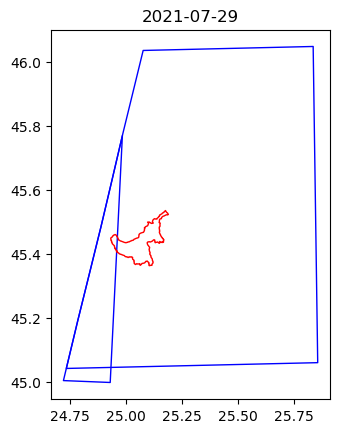

In [30]:
# Visuell überprüfen, ob die AOI effektiv von den selektierten Tiles in der Szene abgedeckt wird
# --> Geometrie des Polygons und der selektierten Tiles plotten 

scene = selected_scenes[0] # hier anpassen, um andere Szene (Datum) anzuschauen

tiles = gpd.GeoDataFrame(
    geometry=[shape(i.geometry) for i in scene["items"]],
    crs="EPSG:4326"
)

aoi_gdf = gpd.GeoDataFrame(geometry=[aoi_geom], crs="EPSG:4326")

ax = tiles.plot(edgecolor="blue", facecolor="none")
aoi_gdf.plot(ax=ax, edgecolor="red", facecolor="none")

plt.title(f"{scene['date']}")
plt.show()

### Zusammenfassung & Ergebnis der STAC-Suche

**Kurzbeschrieb, was gemacht wurde:** 

Die Szenenauswahl erfolgte iterativ für jedes Jahr innerhalb eines Hauptloops, wobei vorher definierte Funktionen verwendet wurden. Zunächst wurden geeignete Sentinel-2 Tiles über den STAC-Katalog abgefragt (`search_items`). Anschliessend wurden die gefundenen Tiles nach ihrem Aufnahmedatum gruppiert (`group_by_date`), sodass alle Tiles, die zur selben Aufnahme gehören, zu einer Szene zusammengefasst wurden.

In einem nächsten Schritt wurden die Szenen gefiltert. Dazu gehörte die Entfernung geometrischer Duplikate innerhalb einer Datumsgruppe (`remove_duplicates`) und die Berechnung der räumlichen Abdeckung der AOI durch die zusammengehörigen Tiles (`calculate_coverage`). Es wurden nur Szenen berücksichtigt, die eine nahezu vollständige Abdeckung der AOI (≥ 99 %) aufweisen.

Die verbleibenden validen Szenen wurden anschliessend in der Liste `selected_scenes` gespeichert.


**Ergebnis:**

Die Liste `selected_scenes` enthält die final ausgewählten Szenen (`valid_scenes`) über alle betrachteten Jahre hinweg. Jede Szene wird durch folgende Parameter beschrieben:

- `year` --> Jahr der Aufnahme
- `date` --> Aufnahmedatum der Szene
- `items` --> Liste der zugehörigen STAC-Items (Tiles), die gemeinsam die Szene bilden
- `coverage` --> Anteil der AOI, der durch die Szene abgedeckt wird (0–1)
- `n_tiles` --> Anzahl der Tiles, aus denen die Szene besteht

Die enthaltenen STAC-Items umfassen sowohl Metadaten (z.B. Aufnahmezeitpunkt, Wolkenbedeckung und Geometrie) als auch Referenzen (Assets) zu den entsprechenden Rasterdaten.

Die eigentlichen Bilddaten wurden jedoch noch nicht geladen. Um diese für die Analyse zu nutzen, müssen die referenzierten Rasterdaten aus der Cloud abgerufen und verarbeitet werden.

`stackstac` ist ein Tool, das Satellitendaten aus STAC-Katalogen in ein analysierbares, multidimensionales Python-Datenformat (`xarray` + `dask`) verwandelt (siehe auch [stackstac](https://stackstac.readthedocs.io/en/latest/))

## Wolkenärmste Szene pro Jahr bestimmen {#sec-best_scene}

In `selected_scenes` liegen mehrere mögliche Szenen aus `valid_scenes`. Aus diesen soll pro Untersuchungszeitraum, beziehungsweise pro Jahr, jeweils die wolkenärmste Szene ausgewählt werden. Dabei ist nicht der globale Wolkenanteil der gesamten Sentinel-2-Szene entscheidend, sondern der Wolkenanteil innerhalb der AOI. Dies ist wichtig, da eine Szene global zwar einen geringen Wolkenanteil aufweisen kann, die vorhandenen Wolken jedoch genau über der AOI liegen können. Umgekehrt kann eine Szene einen höheren globalen Wolkenanteil haben, während die AOI selbst weitgehend wolkenfrei ist.

Der Wolkenanteil über der AOI wird anhand des SCL-Layers bestimmt. Dazu wird der SCL-Layer gestacked, aus den einzelnen Tiles ein Mosaik gebildet und dieses anschliessend auf die AOI zugeschnitten. Danach werden die Wolken- und Wolkenschattenpixel innerhalb der AOI gezählt. Auf Basis dieser Information kann pro Jahr jene Szene mit dem geringsten Wolkenanteil über der AOI ausgewählt und für die weitere Analyse beibehalten werden.

**Testlauf mit nur einem Jahr:** Zunächst wird der Ablauf nur für ein einzelnes Jahr durchgeführt, anstatt direkt alle Jahre in einer Schleife zu verarbeiten. Dadurch lassen sich mögliche Fehler einfacher erkennen und beheben. Sobald der Ablauf für ein Jahr korrekt funktioniert, kann er auf alle Jahre übertragen und in einer Schleife automatisiert werden.

### Polygon in gewünschtes CRS bringen

Für die STAC-Suche nach geeigneten Sentinel-2-Tiles wurde die AOI zunächst im Koordinatenreferenzsystem **WGS84** (`EPSG:4326`) verwendet, da die räumliche Suche über den STAC-Katalog Geometrien in geografischen Koordinaten erwartet.

Für die anschliessende Rasterverarbeitung wird die AOI jedoch in ein **metrisches Koordinatenreferenzsystem** transformiert. Dazu wird mittels `estimate_utm_crs()` automatisch eine zur Lage der AOI passende UTM-Zone bestimmt. Ein metrisches Koordinatensystem ist für die weitere Analyse sinnvoll, da Sentinel-2-Raster eine räumliche Auflösung in Metern besitzen und Operationen wie Clipping, Rasterauswahl, Distanz- und Flächenbezüge dadurch konsistenter durchgeführt werden können.

Der entsprechende EPSG-Code wird gespeichert, damit die Sentinel-2-Daten später direkt in diesem Koordinatenreferenzsystem geladen und verarbeitet werden können. Zusätzlich werden die räumlichen Grenzen (`bounds`) der AOI berechnet. Diese dienen dazu, beim Laden der Rasterdaten nur den für die AOI relevanten Ausschnitt zu berücksichtigen.

In [31]:
# für spätere Rasteranalyse in metrischem Koordinatensystem arbeiten 
# --> Polygon in neues Koordinatensystem bringen
# --> für die AOI passendes EPSG automatisch bestimmen lassen

aoi_utm = aoi.to_crs(aoi.estimate_utm_crs()) # bestimmt das passende EPSG
print(aoi_utm.crs)     

epsg = int(aoi_utm.crs.to_epsg())            # nimmt das EPSG als string
print(epsg)
print(type(epsg))

bounds = aoi_utm.geometry.iloc[0].bounds     # nimmt die bounds des Polygons 
print(bounds)

EPSG:32635
32635
<class 'int'>
(338314.97924269666, 5024980.196869277, 358571.55387418973, 5043985.579151628)


### Testjahr & Testszene definieren

In [32]:
year_test = years[2]
scenes_test = [s for s in selected_scenes if s["year"] == year_test]

In [33]:
len(scenes_test)

7

In [34]:
scenes_test[:2]

[{'year': 2023,
  'date': datetime.date(2023, 7, 29),
  'items': [<Item id=S2B_MSIL2A_20230729T090559_R050_T35TLL_20241022T060949>,
   <Item id=S2B_MSIL2A_20230729T090559_R050_T35TLL_20230729T134430>,
   <Item id=S2B_MSIL2A_20230729T090559_R050_T34TGR_20241022T060949>,
   <Item id=S2B_MSIL2A_20230729T090559_R050_T34TGR_20230729T140713>],
  'coverage': 0.9999999999999987,
  'n_tiles': 4},
 {'year': 2023,
  'date': datetime.date(2023, 7, 24),
  'items': [<Item id=S2A_MSIL2A_20230724T090601_R050_T35TLL_20230724T181320>,
   <Item id=S2A_MSIL2A_20230724T090601_R050_T34TGR_20230724T161638>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2}]

In [35]:
# Szene zum Testen meiner Funktion
scene_test = scenes_test[0]

In [36]:
scene_test

{'year': 2023,
 'date': datetime.date(2023, 7, 29),
 'items': [<Item id=S2B_MSIL2A_20230729T090559_R050_T35TLL_20241022T060949>,
  <Item id=S2B_MSIL2A_20230729T090559_R050_T35TLL_20230729T134430>,
  <Item id=S2B_MSIL2A_20230729T090559_R050_T34TGR_20241022T060949>,
  <Item id=S2B_MSIL2A_20230729T090559_R050_T34TGR_20230729T140713>],
 'coverage': 0.9999999999999987,
 'n_tiles': 4}

### Funktionen für die Selektion definieren

#### 1. Stack der SCL-Layer erstellen

Mit der Funktion `load_scl_stack` werden die Scene Classification Layer (SCL) der ausgewählten Sentinel-2 Items geladen und zu einem mehrdimensionalen Datenstapel verarbeitet.

Dabei werden nur die SCL-Bänder aus den jeweiligen STAC-Items extrahiert (`assets=["SCL"]`). 

Über die Parameter `bounds` und `epsg` wird der räumliche Ausschnitt sowie das Zielkoordinatensystem definiert, sodass die Daten direkt auf die Untersuchungsregion (AOI) zugeschnitten und in ein metrisches Koordinatensystem überführt werden.

Das Resultat ist ein `xarray.DataArray` (`scl_stack`), welches alle relevanten SCL-Daten der übergebenen Szenen in einer gemeinsamen, analysierbaren Struktur enthält und die Grundlage für die anschliessende Mosaikbildung und Wolkenanalyse bildet.

In [37]:
def load_scl_stack(items, bounds, epsg):

    scl_stack = stackstac.stack(
        items,
        assets=["SCL"],
        resolution=20,
        bounds=bounds,
        epsg=epsg
    )

    return scl_stack

In [38]:
# Überprüfen mit einer Szene

stack = load_scl_stack(
    scene_test["items"],
    bounds,
    epsg
)

print(stack)

<xarray.DataArray 'stackstac-b8fd1f9a2d50fd76de24e5314e97ecd7' (time: 4,
                                                                band: 1,
                                                                y: 951, x: 1014)> Size: 31MB
dask.array<fetch_raster_window, shape=(4, 1, 951, 1014), dtype=float64, chunksize=(1, 1, 951, 1014), chunktype=numpy.ndarray>
Coordinates: (12/41)
  * time                                     (time) datetime64[ns] 32B 2023-0...
    id                                       (time) <U54 864B 'S2B_MSIL2A_202...
    s2:nodata_pixel_percentage               (time) float64 32B 33.74 ... 94.55
    s2:vegetation_percentage                 (time) float64 32B 69.62 ... 75.82
    s2:generation_time                       (time) <U27 432B '2024-10-22T06:...
    s2:cloud_shadow_percentage               (time) float64 32B 5.031 ... 3.504
    ...                                       ...
    platform                                 <U11 44B 'Sentinel-2B'
    s2:reflec

#### 2. Mosaik bilden aus mehreren Tiles

Mit der stackstac-Funktion `.mosaic()` (siehe [Dokumentation](https://stackstac.readthedocs.io/en/latest/api/main/stackstac.mosaic.html)) wird entlang der Zeitdimension ein Mosaik gebildet, wobei für jedes Pixel in überlappenden Szenen genau ein Wert ausgewählt wird (*"Flatten a dimension of a DataArray by picking the first valid pixel"*). Standardmässig gilt dabei das Prinzip "last valid observation wins", d.h. wenn mehrere Werte für ein Pixel vorhanden sind, wird der zuletzt vorhandene gültige Wert übernommen. Das Resultat ist ein zusammenhängendes Raster, das aus mehreren Sentinel-2 Tiles zu einer Szene zusammengesetzt wird.

Output: `xarray.DataArray`

In [39]:
def build_scl_mosaic(scl_stack):
    
    scl_mosaic = stackstac.mosaic(scl_stack, dim="time")

    return scl_mosaic

In [40]:
# Überprüfen mit einer Szene

mosaic = build_scl_mosaic(stack)

print(mosaic) # Zeitdimension wurde auf 1 reduziert

<xarray.DataArray 'stackstac-b8fd1f9a2d50fd76de24e5314e97ecd7' (band: 1,
                                                                y: 951, x: 1014)> Size: 8MB
dask.array<mosaic-aggregate, shape=(1, 951, 1014), dtype=float64, chunksize=(1, 951, 1014), chunktype=numpy.ndarray>
Coordinates: (12/17)
  * band                                     (band) <U3 12B 'SCL'
  * y                                        (y) float64 8kB 5.044e+06 ... 5....
  * x                                        (x) float64 8kB 3.383e+05 ... 3....
    sat:orbit_state                          <U10 40B 'descending'
    s2:snow_ice_percentage                   float64 8B 0.0
    sat:relative_orbit                       int64 8B 50
    ...                                       ...
    platform                                 <U11 44B 'Sentinel-2B'
    s2:reflectance_conversion_factor         float64 8B 0.9693
    proj:shape                               object 8B {5490}
    title                                 

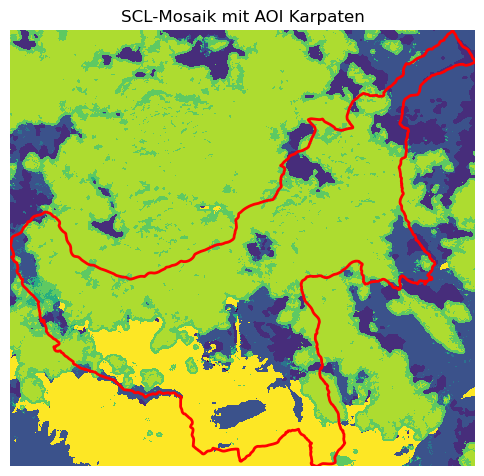

In [41]:
# Überprüfen mittels Plot

# Plot des SCL-Layers erstellen
fig, ax = plt.subplots(figsize=(6, 6))

mosaic.plot(
    ax=ax,
    add_colorbar=False   # keine Farblegende
)

# AOI-Polygon darüberlegen
aoi_utm.plot(
    ax = ax, 
    facecolor = "none",
    edgecolor = "red", 
    linewidth = 2
)

plt.title(f"SCL-Mosaik mit AOI {aoi_name}")

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

plt.show()

#### 3. Auf AOI clippen
Da der Wolkenanteil nur innerhalb der AOI berechnet werden soll, werden die SCL-Layer im `scl_stack` auf die AOI zugeschnitten. Dafür wird die Funktion `.rio.clip()` von *rioxarray* verwendet. Als Maske werden die Polygon-Geometrie der AOI sowie das zugehörige CRS übergeben.

In [42]:
def clip_to_aoi(scl_mosaic, aoi_utm):
    
    scl_clipped = scl_mosaic.rio.clip(
    aoi_utm.geometry,
    aoi_utm.crs,
    drop=True        
    )

    return scl_clipped

In [43]:
# Clip ausführen
clipped = clip_to_aoi(mosaic, aoi_utm)

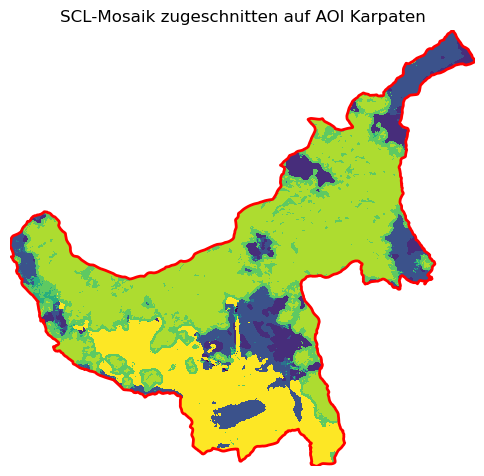

In [44]:
# Überprüfen mittels Plot

# Plot des SCL-Layers erstellen
fig, ax = plt.subplots(figsize=(6, 6))

clipped.plot(
    ax=ax,
    add_colorbar=False   # keine Farblegende
)

# AOI-Polygon darüberlegen
aoi_utm.plot(
    ax = ax, 
    facecolor = "none",
    edgecolor = "red", 
    linewidth = 2
)

plt.title(f"SCL-Mosaik zugeschnitten auf AOI {aoi_name}")

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

plt.show()

#### 4. Cloud-Maske

In diesem Schritt wird definiert, welche Pixel als Wolken beziehungsweise Wolkenschatten betrachtet werden. Die Zuordnung basiert auf den Pixelwerten des SCL-Layers. Eine Übersicht der möglichen Werte ist in der Sentinel-Hub-Dokumentation unter [Values](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/scene-classification/) aufgeführt.

Folgende SCL-Klassen werden als Wolken- beziehungsweise Wolkenschattenpixel maskiert:

- `3`: Cloud Shadows
- `8`: Cloud medium probability
- `9`: Cloud high probability
- `10`: Thin cirrus

Zur Identifikation dieser Pixel wird die Funktion `.isin()` von *xarray* verwendet. Diese prüft für jedes Pixel im `xarray.DataArray`, ob der jeweilige Pixelwert in den definierten `cloud_classes` enthalten ist. Trifft dies zu, erhält das Pixel den Wert `True`; andernfalls erhält es den Wert `False`.

Dadurch entsteht eine binäre Cloud-Maske, mit der die Wolken- und Wolkenschattenpixel innerhalb der AOI gezählt werden können.

In [45]:
def compute_cloud_mask(scl_clipped):
    
    cloud_classes = [3, 8, 9, 10]

    # Pixel innerhalb der AOI / gültige SCL-Pixel
    inside_aoi = scl_clipped.notnull()

    # True = Wolke/Schatten, aber nur innerhalb AOI
    cloud_mask = scl_clipped.isin(cloud_classes) & inside_aoi
    
    return cloud_mask, inside_aoi

In [46]:
cloud_mask, inside_aoi = compute_cloud_mask(clipped)

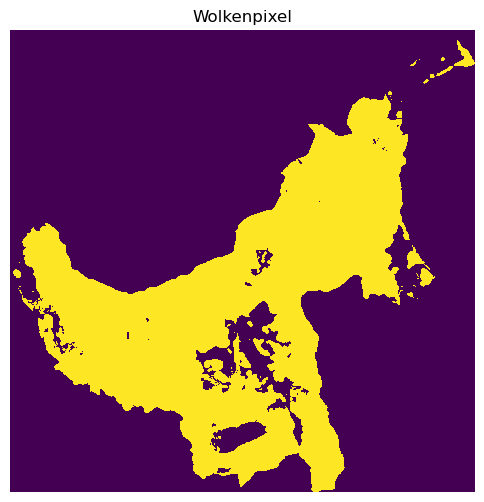

In [47]:
# Überprüfen: nur 0 und 1 Werte

# Plot des SCL-Layers erstellen
fig, ax = plt.subplots(figsize=(6, 6))

cloud_mask.plot(
    ax=ax,
    add_colorbar=False   # keine Farblegende
)

plt.title("Wolkenpixel")

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

plt.show()

In [48]:
# Raster ist nun rechteckig. Daten jedoch immer noch geclipped?
print(clipped.shape)
print(cloud_mask.shape)

(1, 950, 1013)
(1, 950, 1013)


In [49]:
# Anzahl Wolkenpixel innerhalb AOI
cloud_pixels = cloud_mask.sum().compute().item()
print(cloud_pixels)

281541


In [50]:
# Anzahl gültige Pixel innerhalb AOI
total_pixels = inside_aoi.sum().compute().item()
print(total_pixels)

329479


#### 5. Cloud-Anteil berechnen

Der Wolkenanteil innerhalb der AOI wird als relativer Anteil zwischen `0` und `1` berechnet. Grundlage dafür ist die zuvor erstellte Cloud-Maske, in der Wolken- und Wolkenschattenpixel den Wert `True` und wolkenfreie Pixel den Wert `False` erhalten.

Da Python `True` wie `1` und `False` wie `0` behandelt, entspricht der Mittelwert der Maske direkt dem Wolkenanteil innerhalb der AOI. Ein Wert von `0` bedeutet, dass keine Wolken- oder Wolkenschattenpixel vorhanden sind, während ein Wert von `1` einer vollständig bedeckten AOI entspricht.

Da `stackstac` die Daten zunächst *lazy* verarbeitet, wird die Berechnung mit `.compute()` explizit ausgeführt. Anschliessend wandelt `.item()` das Ergebnis in einen einzelnen Python-`float` um (statt *Array*).

In [51]:
def compute_cloud_fraction(cloud_mask, inside_aoi):
    cloud_fraction = (cloud_mask.sum() / inside_aoi.sum()).compute().item()
    return cloud_fraction

In [52]:
clouds_faction = compute_cloud_fraction(cloud_mask, inside_aoi)
clouds_faction

0.85450362542074

In [53]:
type(clouds_faction)

float

In [54]:
cloud_pixels/total_pixels == clouds_faction

True

### Funktionen verbinden, Loops

#### Pipeline für jede Szene

In diesem Schritt werden die zuvor definierten Funktionen zu einer Pipeline zusammengeführt. Die Pipeline dient dazu, eine einzelne `scene` aus `selected_scenes` standardisiert zu verarbeiten und den Wolkenanteil über der AOI zu berechnen.

In [55]:
def process_scene(scene, bounds, epsg, aoi_utm):

    # 1. SCL-Layer laden
    scl_stack = load_scl_stack(scene["items"], bounds, epsg)

    # 2. Mosaik aus mehreren Tiles bauen
    scl = build_scl_mosaic(scl_stack)

    # 3. Auf AOI clippen
    scl = clip_to_aoi(scl, aoi_utm)

    # 4. Wolken maskieren (True / False)
    cloud_mask, inside_aoi = compute_cloud_mask(scl)

    # 5. Wolkenanteil berechnen [0-1]
    cloud_fraction = compute_cloud_fraction(cloud_mask, inside_aoi)

    return cloud_fraction

In [56]:
# Überprüfen

process_scene(scene_test, bounds, epsg, aoi_utm)

0.85450362542074

In [57]:
# gleiches Resultat wie vorhin? 

process_scene(scene_test, bounds, epsg, aoi_utm) == clouds_faction

True

#### Loop über ein Jahr (Testlauf)

In der Funktion `process_scene` wurde die Pipeline zur Verarbeitung aller Szenen innerhalb `selected_scenes` erstellt. 


In diesem Testlauf wird die Funktion `process_scene` auf alle validen Szenen eines einzelnen Testjahres (`scenes_test`) angewendet. Für jede Szene wird der SCL-Layer geladen, zu einem Mosaik zusammengeführt, auf die AOI zugeschnitten und daraus der Wolkenanteil innerhalb der AOI berechnet.

Die Ergebnisse werden in der Liste `results` gespeichert. Für jede Szene werden dabei das Jahr, das Aufnahmedatum, der berechnete Wolkenanteil (`cloud_fraction`), die zugehörigen STAC-Items, die räumliche Abdeckung (`coverage`) sowie die Anzahl der Tiles (`n_tiles`) gesichert. Diese Ergebnisliste bildet die Grundlage, um im nächsten Schritt die wolkenärmste Szene des Testjahres auszuwählen.

In [58]:
results = []

for scene in scenes_test:

    cf = process_scene(scene, bounds, epsg, aoi_utm)

    results.append({
    "year": scene["year"],
    "date": scene["date"],
    "cloud_fraction": cf,
    "items": scene["items"],
    "coverage": scene["coverage"],
    "n_tiles": scene["n_tiles"]
    })

In [59]:
len(results)

7

In [60]:
results[ :2]

[{'year': 2023,
  'date': datetime.date(2023, 7, 29),
  'cloud_fraction': 0.85450362542074,
  'items': [<Item id=S2B_MSIL2A_20230729T090559_R050_T35TLL_20241022T060949>,
   <Item id=S2B_MSIL2A_20230729T090559_R050_T35TLL_20230729T134430>,
   <Item id=S2B_MSIL2A_20230729T090559_R050_T34TGR_20241022T060949>,
   <Item id=S2B_MSIL2A_20230729T090559_R050_T34TGR_20230729T140713>],
  'coverage': 0.9999999999999987,
  'n_tiles': 4},
 {'year': 2023,
  'date': datetime.date(2023, 7, 24),
  'cloud_fraction': 0.5181817354065055,
  'items': [<Item id=S2A_MSIL2A_20230724T090601_R050_T35TLL_20230724T181320>,
   <Item id=S2A_MSIL2A_20230724T090601_R050_T34TGR_20230724T161638>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2}]

#### Beste Szene des Jahres auswählen (Testlauf):

Nachdem für alle validen Szenen des Testjahres der Wolkenanteil innerhalb der AOI berechnet wurde, kann nun die wolkenärmste Szene ausgewählt werden. 

Mit der Funktion `min()` wird jenes Dictionary aus `results` ausgewählt, bei dem der Wert von `cloud_fraction` am kleinsten ist. Die Angabe `key=lambda x: x["cloud_fraction"]` legt fest, dass der Vergleich nicht über das ganze Dictionary erfolgt, sondern ausschliesslich über den berechneten Wolkenanteil.

Die ausgewählte Szene wird in der Variable `best_scene` gespeichert. Diese Szene weist innerhalb der AOI den geringsten Wolkenanteil des Testjahres auf und ist damit die geeignetste Szene für die weitere Verarbeitung.

In [61]:
best_scene = min(results, key=lambda x: x["cloud_fraction"])

best_scene

{'year': 2023,
 'date': datetime.date(2023, 7, 9),
 'cloud_fraction': 0.00390616700912653,
 'items': [<Item id=S2B_MSIL2A_20230709T090559_R050_T35TLL_20241018T102750>,
  <Item id=S2B_MSIL2A_20230709T090559_R050_T35TLL_20230709T140728>,
  <Item id=S2B_MSIL2A_20230709T090559_R050_T34TGR_20241018T102750>,
  <Item id=S2B_MSIL2A_20230709T090559_R050_T34TGR_20230709T140434>],
 'coverage': 0.9999999999999987,
 'n_tiles': 4}

#### Loop über alle Jahre

In der Liste `selected_scenes` sind alle validen Szenen gespeichert, welche die AOI im jeweiligen Untersuchungsjahr ausreichend abdecken. Nachdem die Verarbeitung zunächst für ein einzelnes Testjahr getestet wurde, wird die Pipeline nun auf alle Jahre angewendet.

Der Loop durchläuft alle Szenen in `selected_scenes` und berechnet für jede Szene mit `process_scene()` den Wolkenanteil innerhalb der AOI. Die Resultate werden in der Liste `results` gespeichert. Jeder Eintrag enthält unter anderem das Jahr, das Aufnahmedatum, die zugehörigen STAC-Items, die räumliche Abdeckung, die Anzahl der Tiles sowie den berechneten Wolkenanteil (`cloud_fraction`).

Auf Grundlage von `cloud_fraction` kann anschliessend pro Jahr die wolkenärmste Szene ausgewählt werden.

In [62]:
results = []

for scene in selected_scenes:

    cf = process_scene(scene, bounds, epsg, aoi_utm)

    results.append({
    "year": scene["year"],
    "date": scene["date"],
    "cloud_fraction": cf,
    "items": scene["items"],
    "coverage": scene["coverage"],
    "n_tiles": scene["n_tiles"]
    })

In [63]:
len(results)

40

In [64]:
results[:2]

[{'year': 2021,
  'date': datetime.date(2021, 7, 29),
  'cloud_fraction': 3.0350948011861152e-06,
  'items': [<Item id=S2B_MSIL2A_20210729T090559_R050_T35TLL_20210802T042530>,
   <Item id=S2B_MSIL2A_20210729T090559_R050_T34TGR_20210802T033815>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2021,
  'date': datetime.date(2021, 7, 27),
  'cloud_fraction': 0.44532124960923153,
  'items': [<Item id=S2A_MSIL2A_20210727T092031_R093_T35TLL_20210727T204706>,
   <Item id=S2A_MSIL2A_20210727T092031_R093_T34TGR_20210727T210232>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2}]

In [65]:
# Überprüfen: entspricht dies meiner Anzahl an Einträgen in selected_scenes?

len(selected_scenes) == len(results)

True

### Beste Szene pro Untersuchungszeitraum auswählen

Für alle validen Szenen in `selected_scenes` wurde der Wolkenanteil innerhalb der AOI berechnet und in der Liste `results` gespeichert. Nun wird für jedes Untersuchungsjahr jene Szene ausgewählt, welche den kleinsten Wert für `cloud_fraction` aufweist.

Dazu werden die Einträge in `results` nach Jahr gruppiert. Innerhalb jeder Jahresgruppe wird anschliessend die Szene mit dem geringsten Wolkenanteil bestimmt. Die resultierenden Szenen werden in der Liste `best_scenes` gespeichert und für die weitere Verarbeitung verwendet.

#### Nach Jahr gruppieren

Um die bewerteten Szenen nach Jahr zu gruppieren, wird ein leeres Dictionary `by_year` erstellt. Der Loop durchläuft alle Einträge in `results` und liest für jede Szene das zugehörige Jahr mit `r["year"]` aus.

Wenn dieses Jahr noch nicht in `by_year` vorhanden ist, wird dafür eine neue leere Liste erstellt. Anschliessend wird die aktuelle Szene dieser Liste hinzugefügt. So entsteht ein Dictionary, in dem jedem Untersuchungsjahr alle zugehörigen bewerteten Szenen zugeordnet sind.

Diese Struktur ermöglicht es, im nächsten Schritt pro Jahr die Szene mit dem geringsten Wolkenanteil (`cloud_fraction`) auszuwählen.

In [66]:
by_year = {}

for r in results:
    year = r["year"]

    if year not in by_year:
        by_year[year] = []

    by_year[year].append(r)

In [67]:
# by_year

#### Beste Szene pro Jahr wählen

Innerhalb jeder Jahresgruppe wird mit `min()` jene Szene bestimmt, deren `cloud_fraction` [0-1] am kleinsten ist. Diese Szene wird der Liste `best_scenes` hinzugefügt. Mit `print()` werden Jahr, Aufnahmedatum und Wolkenanteil der ausgewählten Szene zur Kontrolle ausgegeben.

Die Liste `best_scenes` enthält somit für jedes Untersuchungsjahr die wolkenärmste verfügbare Szene und wird für die weitere Verarbeitung verwendet.

In [68]:
best_scenes = []

for year, items in by_year.items():

    best = min(items, key=lambda x: x["cloud_fraction"])
    best_scenes.append(best)

    print(year, best["date"], best["cloud_fraction"])

2021 2021-07-29 3.0350948011861152e-06
2022 2022-07-22 0.0
2023 2023-07-09 0.00390616700912653
2024 2024-07-13 0.013588119424910236
2025 2025-07-26 0.0


In [69]:
len(best_scenes)

5

In [70]:
len(best_scenes) == len(years)

True

In [71]:
type(best_scenes)

list

In [72]:
best_scenes

[{'year': 2021,
  'date': datetime.date(2021, 7, 29),
  'cloud_fraction': 3.0350948011861152e-06,
  'items': [<Item id=S2B_MSIL2A_20210729T090559_R050_T35TLL_20210802T042530>,
   <Item id=S2B_MSIL2A_20210729T090559_R050_T34TGR_20210802T033815>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2022,
  'date': datetime.date(2022, 7, 22),
  'cloud_fraction': 0.0,
  'items': [<Item id=S2A_MSIL2A_20220722T092041_R093_T35TLL_20240711T113555>,
   <Item id=S2A_MSIL2A_20220722T092041_R093_T34TGR_20240711T113555>],
  'coverage': 0.9999999999999987,
  'n_tiles': 2},
 {'year': 2023,
  'date': datetime.date(2023, 7, 9),
  'cloud_fraction': 0.00390616700912653,
  'items': [<Item id=S2B_MSIL2A_20230709T090559_R050_T35TLL_20241018T102750>,
   <Item id=S2B_MSIL2A_20230709T090559_R050_T35TLL_20230709T140728>,
   <Item id=S2B_MSIL2A_20230709T090559_R050_T34TGR_20241018T102750>,
   <Item id=S2B_MSIL2A_20230709T090559_R050_T34TGR_20230709T140434>],
  'coverage': 0.9999999999999987,
  'n_tiles'

In [74]:
# Als Tabelle speichern für Ergbenisteil

best_scenes_table = []

for data in best_scenes:
    best_scenes_table.append({
        "Jahr": data["year"],
        "Datum": data["date"],
        "Wolkenanteil_AOI_%": data["cloud_fraction"] * 100,
        "Anzahl_Tiles": len(data["items"]),
        "AOI_Abdeckung_%": data["coverage"] * 100
    })

best_scenes_df = pd.DataFrame(best_scenes_table)

# Werte runden
best_scenes_df["Wolkenanteil_AOI_%"] = best_scenes_df["Wolkenanteil_AOI_%"].round(4)
best_scenes_df["AOI_Abdeckung_%"] = best_scenes_df["AOI_Abdeckung_%"].round(2)

best_scenes_df

,Jahr,Datum,Wolkenanteil_AOI_%,Anzahl_Tiles,AOI_Abdeckung_%
0,2021,2021-07-29,0.0003,2,100.0
1,2022,2022-07-22,0.0000,2,100.0
2,2023,2023-07-09,0.3906,4,100.0
3,2024,2024-07-13,1.3588,2,100.0
4,2025,2025-07-26,0.0000,2,100.0


In [75]:
# als csv speichern
best_scenes_df.to_csv("best_scenes_table.csv", index=False)

## Preprocessing {#sec-prepro}

### Rasterdaten aus STAC-Items stacken/laden

- Aus ausgewählten Satellitenszenen (aus `best_scenes`) echte Rasterdaten laden
- im automatisch bestimmten metrischen Koordinatensystem der AOI (`epsg`)

siehe auch [STAC + stackstac + xarray](https://hrodmn.dev/posts/stackstac/):

*"When you use stackstac, **you do not need to write any code to handle merging operations for many raster files.** The data come out the other side in a neatly packaged xarray object with x, y, time, and band dimensions! This is very convenient when you are interested in an arbitrary area that may **require combining data from many STAC items**. The [stackstac documentation](https://stackstac.readthedocs.io/en/latest/) is very good, but I have put this demo together to highlight a few things that I really like about the STAC + stackstac + xarray workflow."*

--> "**Lazily load the raster data into an `xarray.DataArray` using `stackstac.stack`**. This function uses the STAC item metadata to construct a multidimensional array with human-readable coordinates that can be manipulated with the magnificently powerful suite of `xarray` functions and methods!"


Um die Outputs zu speichern werden Ordner angelegt, in welche die Plots / Composites später gespeichert werden.

**Testlauf mit nur einem Jahr**: Es wird zuerst nur eine Szene bearbeitet (anstatt alle Szenen in einem Loop). Weil: Debugging sonst sehr schwierig. Anschliessend Schlaufe über alle Szenen, wenn alles funktioniert hat.

In [72]:
# Ordner für Outputs anlegen

os.makedirs("Composites_GeoTIFF", exist_ok=True)
os.makedirs("Composites_Plots", exist_ok=True)

In [73]:
# Testjahr definieren
scene_test = best_scenes[0]

In [74]:
scene_test

{'year': 2021,
 'date': datetime.date(2021, 7, 29),
 'cloud_fraction': 3.0350948011861152e-06,
 'items': [<Item id=S2B_MSIL2A_20210729T090559_R050_T35TLL_20210802T042530>,
  <Item id=S2B_MSIL2A_20210729T090559_R050_T34TGR_20210802T033815>],
 'coverage': 0.9999999999999987,
 'n_tiles': 2}

Da im Stack-Cube die Auflösung automatisch angeglichen wird (resampling), werden zwei getrennte Stacks erstellt --> einen für die Bänder, mit denen gearbeitet wird (Red, NIR etc.) und einen für den SCL-Layer (für Wolkenmaskierung). 

Resampling:

- `bilinear` für kontinuierliche Werte (Bänder)
- `nearest` für den SCL-Layer (dieser soll keine Mischung aus Nachbarpixeln machen, da sonst verfälscht)

In [75]:
len(scene_test["items"]) # --> ich habe 2 items (Tiles) in meiner "Szene"

2

**Funktion `stack_rasters`**: Mit dieser Funktion werden für jede Szene in `best_scenes` zwei DataStacks erstellt:

- einer für die Rasterbänder (R, G, B, NIR etc.) --> `stack_bands`
- einer für den SCL-Layer --> `stack_scl`

In [76]:
def stack_rasters(scene, bands, scl, bounds, epsg):

    # STAC-Items aus Dict holen
    items = scene["items"]

    # Spektralbänder stacken
    stack_bands = stackstac.stack(
        items,                              # nimmt das STAC-item
        assets = bands,                     # nimmt die angegebenen Bänder 
        resolution = 10,                    # definiert Auflösung --> automatisches resampling!
        resampling = Resampling.bilinear,   # bilienear da kontinuierliche Pixelwerte
        bounds = bounds,                    # nur Ausschnitt laden statt ganze Tiles
        epsg=epsg,                          # CRS des Polygons übernehmen
    )

    # SCL-Layer stacken
    stack_scl = stackstac.stack(
        items,                
        assets = scl,                  
        resolution = 10,                    # definiert Auflösung --> automatisches resampling!
        resampling = Resampling.nearest,    # hier nearest (!!) da kategorische Pixelwerte
        bounds = bounds,               
        epsg=epsg,                     
    )

    return stack_bands, stack_scl

In [77]:
# Überprüfen mit Test-Szene:

stack_bands, stack_scl = stack_rasters(
    scene_test,
    bands,
    scl,
    bounds,
    epsg
)

In [78]:
print(stack_bands)

<xarray.DataArray 'stackstac-27f931b70d04684a9d94e782ca51a137' (time: 2,
                                                                band: 5,
                                                                y: 1901, x: 2027)> Size: 308MB
dask.array<fetch_raster_window, shape=(2, 5, 1901, 2027), dtype=float64, chunksize=(1, 1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/43)
  * time                                     (time) datetime64[ns] 16B 2021-0...
    id                                       (time) <U54 432B 'S2B_MSIL2A_202...
    s2:not_vegetated_percentage              (time) float64 16B 3.02 1.118
    s2:nodata_pixel_percentage               (time) float64 16B 33.26 94.24
    s2:medium_proba_clouds_percentage        (time) float64 16B 1.588 0.4116
    s2:cloud_shadow_percentage               (time) float64 16B 0.2147 0.1467
    ...                                       ...
    s2:datatake_type                         <U8 32B 'INS-NOBS'
    s2:product_type         

In [79]:
print(type(stack_bands))

<class 'xarray.core.dataarray.DataArray'>


In [80]:
# welche Bänder sind im Stack?
print(stack_bands.band.values)

['B02' 'B03' 'B04' 'B08' 'B12']


### Mosaik erstellen

Mit `stackstac.stack()` wird jedem übergebenen STAC-Item eine eigene Zeitkoordinate zugewiesen. Da eine Sentinel-2-Szene für die AOI jedoch aus mehreren Tiles bestehen kann, liegen diese Tiles zunächst als separate Einträge entlang der `time`-Dimension vor.

Für die weitere Analyse sollen die Tiles einer Szene nicht einzeln ausgewertet werden. Stattdessen werden sie zu einem gemeinsamen Mosaik zusammengeführt. Dadurch entsteht aus mehreren Tiles ein einzelnes Raster.

Dafür wird die Funktion [`stackstac.mosaic()`](https://stackstac.readthedocs.io/en/latest/api/main/stackstac.mosaic.html) verwendet. Sie reduziert die `time`-Dimension, indem die einzelnen Tiles einer Szene zu einem zusammenhängenden Mosaik kombiniert werden. Das resultierende Mosaik kann anschliessend als eine einzelne Szene weiterverarbeitet und später mit den Mosaiken der anderen Untersuchungsjahre zu einem Stack zusammengeführt werden.

In [81]:
def create_mosaic(stack_bands, stack_scl):

    stack_bands_mosaic = stackstac.mosaic(stack_bands, dim="time")
    stack_scl_mosaic = stackstac.mosaic(stack_scl, dim="time")

    return stack_bands_mosaic, stack_scl_mosaic

#### Zwischenergebnis überprüfen

In [82]:
# Überprüfen mit Test-Szene:

stack_bands_mosaic, stack_scl_mosaic = create_mosaic(
    stack_bands,
    stack_scl
)

In [83]:
# Ergebnis betrachten: (--> "time" sollte = 1, resp. nicht in oberster Zeile ausgewiesen sein)

print(stack_bands_mosaic)

<xarray.DataArray 'stackstac-27f931b70d04684a9d94e782ca51a137' (band: 5,
                                                                y: 1901, x: 2027)> Size: 154MB
dask.array<mosaic-aggregate, shape=(5, 1901, 2027), dtype=float64, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/21)
  * band                                     (band) <U3 60B 'B02' ... 'B12'
    title                                    (band) <U26 520B 'Band 2 - Blue ...
    gsd                                      (band) float64 40B 10.0 ... 20.0
    common_name                              (band) <U6 120B 'blue' ... 'swir22'
    center_wavelength                        (band) float64 40B 0.49 ... 2.19
    full_width_half_max                      (band) float64 40B 0.098 ... 0.242
    ...                                       ...
    s2:datatake_type                         <U8 32B 'INS-NOBS'
    s2:product_type                          <U7 28B 'S2MSI2A'
    platform                             

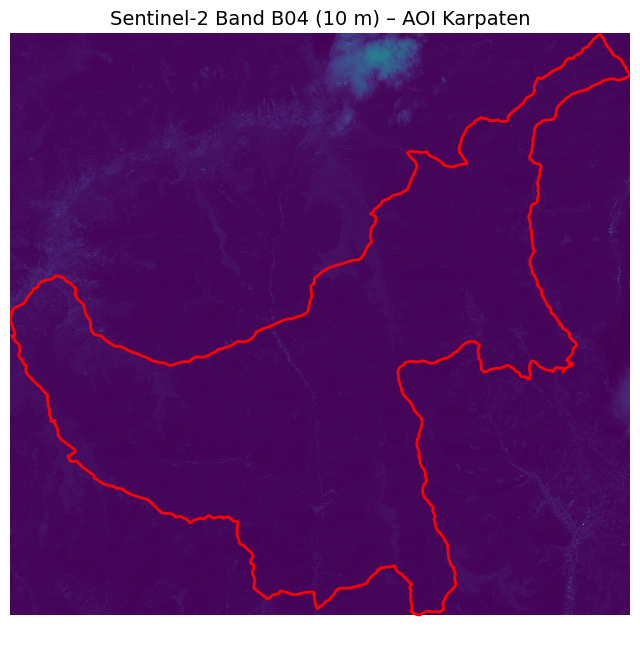

In [84]:
# Figure (gesamtes Bild) + Axes (Plotfläche)
fig, ax = plt.subplots(figsize=(8, 8))

# Raster (Sentinel-2 Band B04) plotten
stack_bands_mosaic.sel(band="B04").plot.imshow(
    ax=ax,
    add_colorbar=False   # keine Farblegende
)

# AOI-Polygon darüberlegen
aoi_utm.plot(
    ax=ax,
    facecolor="none",     # nur Umrandung, keine Füllung
    edgecolor="red",      # rote Linie
    linewidth=2           # Linienbreite
)

# Titel setzen
ax.set_title(f"Sentinel-2 Band B04 (10 m) – AOI {aoi_name}", fontsize=14)

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

# Plot anzeigen
plt.show()

### Auf AOI clippen

Die Mosaike werden auf die Geometrie der AOI zugeschnitten. Dafür wird `rio.clip()` mit der AOI-Geometrie (`aoi_utm.geometry`) und dem zugehörigen Koordinatensystem (`aoi_utm.crs`) verwendet.

Mit `drop=True` werden Bereiche ausserhalb der AOI entfernt. Die Funktion gibt die zugeschnittenen spektralen Bänder (`stack_bands_clipped`) und den zugeschnittenen SCL-Layer (`stack_scl_clipped`) zurück.

In [85]:
def clip_mosaic(stack_bands_mosaic, stack_scl_mosaic, aoi_utm):

    stack_bands_clipped = stack_bands_mosaic.rio.clip(
    aoi_utm.geometry,
    aoi_utm.crs,
    drop=True
    )
    
    stack_scl_clipped = stack_scl_mosaic.rio.clip(
    aoi_utm.geometry,
    aoi_utm.crs,
    drop=True
    )

    return stack_bands_clipped, stack_scl_clipped

#### Zwischenergebnis überprüfen

In [86]:
# Überprüfen mit Test-Szene:

stack_bands_clipped, stack_scl_clipped = clip_mosaic(
    stack_bands_mosaic,
    stack_scl_mosaic,
    aoi_utm
)

In [87]:
# SCL-Klassen (0–11)
classes = list(range(12))

# Farben (ESA-ähnlich / gut unterscheidbar)
colors = [
    "#000000",  # 0: No data
    "#ff0000",  # 1: Saturated/defective
    "#2f2f2f",  # 2: Dark area / shadows
    "#643200",  # 3: Cloud shadows
    "#00a000",  # 4: Vegetation
    "#ffe65a",  # 5: Not vegetated
    "#0000ff",  # 6: Water
    "#808080",  # 7: Unclassified
    "#c0c0c0",  # 8: Cloud medium prob
    "#ffffff",  # 9: Cloud high prob
    "#64c8ff",  # 10: Thin cirrus
    "#ff96ff",  # 11: Snow/ice
]

# Diskrete Colormap
cmap = mcolors.ListedColormap(colors)

# damit matplotlib die Werte nicht als kontinuierlich behandelt
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(0, 12, 1),
    ncolors=12
)

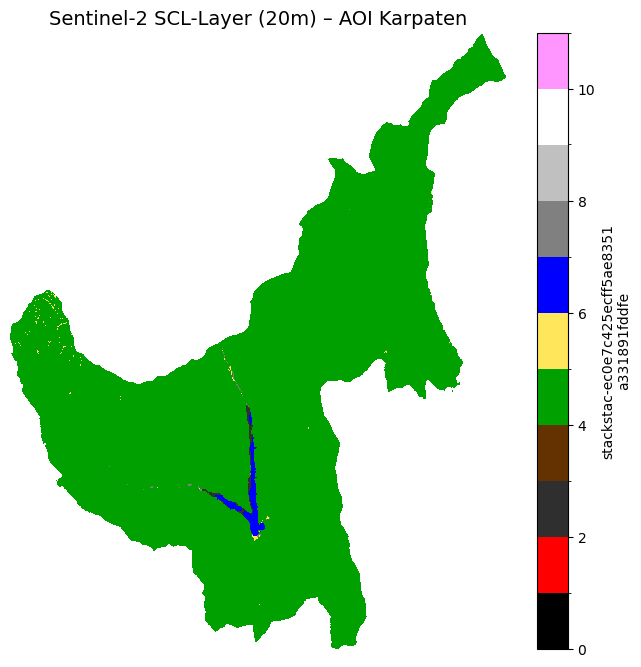

In [88]:
# Figure (gesamtes Bild) + Axes (Plotfläche)
fig, ax = plt.subplots(figsize=(8, 8))

# Raster (SCL-Layer) plotten
stack_scl_clipped.sel(band="SCL").plot.imshow(
    ax=ax,
    cmap = cmap,
    norm = norm
)

# Titel setzen
ax.set_title(f"Sentinel-2 SCL-Layer (20m) – AOI {aoi_name}", fontsize=14)

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

# Plot anzeigen
plt.show()

### Wolkenmaskierung

Für die Wolkenmaskierung werden die SCL-Layer aus `stack_scl_clipped` verwendet. Daraus werden zwei Masken erstellt: `cloud_mask` kennzeichnet gültige Pixel innerhalb der AOI, während `cloud_pixels` die Wolken- und Wolkenschattenpixel innerhalb der AOI enthält. Die Maske `cloud_mask` wird anschliessend mit der Funktion `mask_clouds()` auf den Stack mit den spektralen Bändern (`stack_bands_clipped`) angewendet.

Maskiert werden die folgenden [SCL-Klassen](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/scene-classification/):

- `3`: Cloud Shadows
- `8`: Cloud medium probability
- `9`: Cloud high probability
- `10`: Thin cirrus

Dadurch werden wolken- und schattenbedeckte Pixel in den spektralen Bändern ausgeschlossen und in der weiteren Analyse nicht berücksichtigt.

In [89]:
clouds=[3, 8, 9, 10]

In [90]:
def mask_clouds(stack_bands_clipped, stack_scl_clipped, clouds):

    # SCL-Layer auswählen
    scl_layer = stack_scl_clipped.sel(band="SCL")

    # Pixel innerhalb der AOI / gültige SCL-Pixel
    inside_aoi = scl_layer.notnull()

    # True = gültiger Pixel, False = Wolke/Schatten oder ausserhalb AOI
    cloud_mask = (~scl_layer.isin(clouds)) & inside_aoi

    # True = Wolkenpixel, aber nur innerhalb AOI
    cloud_pixels = scl_layer.isin(clouds) & inside_aoi

    # Maske auf alle Bänder anwenden
    stack_bands_masked = stack_bands_clipped.where(cloud_mask)

    return stack_bands_masked, cloud_mask, cloud_pixels

#### Zwischenergebnis überprüfen

Zur Kontrolle der Wolkenmaskierung wird das Zwischenergebnis später mit den RGB-Composites verglichen. Dadurch kann visuell überprüft werden, ob Wolken- und Schattenbereiche plausibel erkannt und maskiert wurden. Der entsprechende Abgleich erfolgt im Abschnitt [Wolkenmaskierung überprüfen](#sec-clouds_val).

### Loop über alle Szenen / Jahre

In diesem Schritt werden die zuvor definierten Funktionen `stack_rasters()`, `create_mosaic()`, `clip_mosaic()` und `mask_clouds()` in einem Loop auf alle ausgewählten Szenen angewendet. Für jedes Untersuchungsjahr werden die Sentinel-2-Bänder und der SCL-Layer geladen, mosaikiert, auf die AOI zugeschnitten und wolkenmaskiert.

Zusätzlich wird die Wolkenmaske für jedes Jahr gespeichert. Diese wird später für die Zeitreihenanalyse verwendet, damit nur Pixel berücksichtigt werden, die in allen Jahren gültige, wolkenfreie Werte aufweisen. Pixel, die in mindestens einem Jahr von Wolken oder Wolkenschatten betroffen sind, werden dazu ausgeschlossen. Aufgrund des insgesamt geringen Wolkenanteils ist dieser zusätzliche Flächenausschluss vertretbar.

In [91]:
processed_scenes = {}

for scene in best_scenes:

    year = scene["year"]
    date = scene["date"]

    print(f"Processing {year} | {date}")

    # 1. Raster stacken
    stack_bands, stack_scl = stack_rasters(
        scene,
        bands,
        scl,
        bounds,
        epsg
    )

    # 2. Mosaik erstellen
    stack_bands_mosaic, stack_scl_mosaic = create_mosaic(
        stack_bands,
        stack_scl
    )

    # 3. Auf AOI clippen
    stack_bands_clipped, stack_scl_clipped = clip_mosaic(
        stack_bands_mosaic,
        stack_scl_mosaic,
        aoi_utm
    )

    # 4. Wolken maskieren
    stack_bands_masked, cloud_mask, cloud_pixels = mask_clouds(
        stack_bands_clipped,
        stack_scl_clipped,
        clouds
    )

    # 5. Wolkenmaske pro Jahr abspeichern (für spätere Verwendung)
    
    # von Boolean in 1/0 umwandeln
    valid_mask = cloud_mask.astype("uint8") # 1 = gültig, 0 = Wolke
    
    # CRS sicherstellen
    valid_mask = valid_mask.rio.write_crs(f"EPSG:{epsg}")

    # Wolken-Raster speichern (im Ordner Composites_GeoTIFF)
    valid_mask.rio.to_raster(f"Composites_GeoTIFF/ValidMask_{year}.tif")
    print(f"Saved ValidMask_{year} as GeoTIFF")

    # 6. Ergebnisse speichern
    processed_scenes[year] = {
        "date": date,
        "stack_bands": stack_bands_clipped,
        "stack_scl": stack_scl_clipped,
        "stack_bands_masked": stack_bands_masked,
        "cloud_mask": cloud_mask,
        "cloud_pixels": cloud_pixels,
        "cloud_fraction": scene["cloud_fraction"],
        "n_tiles": scene["n_tiles"]
    }

    print(f"Done {year}")

Processing 2021 | 2021-07-29
Saved ValidMask_2021 as GeoTIFF
Done 2021
Processing 2022 | 2022-07-22
Saved ValidMask_2022 as GeoTIFF
Done 2022
Processing 2023 | 2023-07-09
Saved ValidMask_2023 as GeoTIFF
Done 2023
Processing 2024 | 2024-07-13
Saved ValidMask_2024 as GeoTIFF
Done 2024
Processing 2025 | 2025-07-26
Saved ValidMask_2025 as GeoTIFF
Done 2025


In [92]:
len(processed_scenes)

5

In [93]:
print(processed_scenes[years[0]]["stack_bands_masked"])

<xarray.DataArray 'stackstac-27f931b70d04684a9d94e782ca51a137' (band: 5,
                                                                y: 1900, x: 2026)> Size: 154MB
dask.array<where, shape=(5, 1900, 2026), dtype=float64, chunksize=(1, 1023, 1023), chunktype=numpy.ndarray>
Coordinates: (12/21)
  * band                                     (band) <U3 60B 'B02' ... 'B12'
    common_name                              (band) <U6 120B 'blue' ... 'swir22'
    center_wavelength                        (band) float64 40B 0.49 ... 2.19
    full_width_half_max                      (band) float64 40B 0.098 ... 0.242
  * y                                        (y) float64 15kB 5.044e+06 ... 5...
  * x                                        (x) float64 16kB 3.383e+05 ... 3...
    ...                                       ...
    platform                                 <U11 44B 'Sentinel-2B'
    s2:datatake_id                           <U34 136B 'GS2B_20210729T090559_...
    s2:reflectance_conversi

## Composites erstellen {#sec-composites}

Nachdem die Sentinel-2-Bänder wolkenmaskiert wurden, werden daraus die spektralen Indizes berechnet. Wichtig ist, dass dafür der bereits maskierte Stack **`stack_bands_masked`** verwendet wird. Dadurch werden wolken- und schattenbedeckte Pixel nicht in die Berechnung der Indizes einbezogen.

Berechnet werden der NDVI und der NBR:

- $NDVI = (NIR - Red) / (NIR + Red)$  
  entspricht bei Sentinel-2: `(B08 - B04) / (B08 + B04)`

- $NBR = (NIR - SWIR) / (NIR + SWIR)$  
  entspricht bei Sentinel-2: `(B08 - B12) / (B08 + B12)`

Der NDVI wird zur Beschreibung der Vegetationsaktivität verwendet, während der NBR besonders sensitiv auf Veränderungen der Vegetationsstruktur und Störungen wie Waldverlust oder Brandflächen reagiert.

Wie bei den vorherigen Verarbeitungsschritten wird die Berechnung zunächst für ein Testjahr durchgeführt. Anschliessend wird der Workflow in einem Loop auf alle Untersuchungsjahre angewendet.

### RGB-Composite zur Kontrolle

RGB-Composites erstellen: siehe dieses [Script](https://www.satmapper.hu/en/rgb-images/)

Zur visuellen Kontrolle werden RGB-Composites aus den Sentinel-2-Bändern `B04` (Red), `B03` (Green) und `B02` (Blue) erstellt. Diese dienen als Referenz, um die Wolkenmaskierung und die berechneten Indizes visuell zu überprüfen.

Da `stackstac` *lazy* arbeitet, werden die Daten erst mit `.compute()` tatsächlich berechnet und in den Arbeitsspeicher geladen.

Die Erstellung wird zuerst für ein Testjahr geprüft und anschliessend in einem Loop auf alle `stack_bands` in `processed_scenes` angewendet.

In [94]:
year = years[0]

print(processed_scenes[year]["date"])

2021-07-29


In [95]:
test_bands = processed_scenes[year]["stack_bands"]

In [96]:
# RGB-Bänder extrahieren
red = test_bands.sel(band="B04").compute()
green = test_bands.sel(band="B03").compute()
blue = test_bands.sel(band="B02").compute()

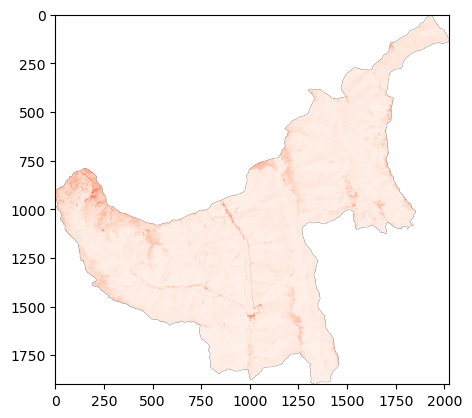

In [97]:
plt.imshow(red, cmap='Reds')

In [98]:
red.shape
# red ist ein 2D-Array 

(1900, 2026)

In [99]:
# Werte normalisieren auf 0-1

def normalize_rgb(band):
    band_min = band.min()
    band_max = band.max()
    return (band - band_min) / (band_max - band_min)

red_n = normalize_rgb(red)
green_n = normalize_rgb(green)
blue_n = normalize_rgb(blue)

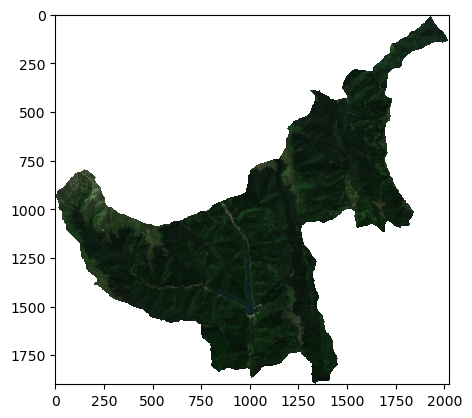

In [100]:
rgb_composite_n= np.dstack((red_n, green_n, blue_n))
plt.imshow(rgb_composite_n)

Bild ist sehr dunkel --> um die Farben zu "verbessern", wird das Bild aufgehellt (Bildmanipulation).

In [101]:
def brighten_rgb(band):
    alpha=0.13
    beta=0
    return np.clip(alpha*band+beta, 0,255)

red_b=brighten_rgb(red)
blue_b=brighten_rgb(blue)
green_b=brighten_rgb(green)

red_bn = normalize_rgb(red_b)
green_bn = normalize_rgb(green_b)
blue_bn = normalize_rgb(blue_b)

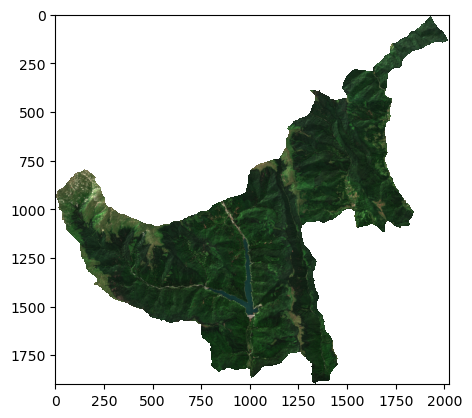

In [102]:
rgb_composite_bn= np.dstack((red_bn, green_bn, blue_bn))
plt.imshow(rgb_composite_bn)

#### Loop über alle Jahre

In [103]:
for year, data in processed_scenes.items():

    print(f"Processing RGB {year}")

    stack = data["stack_bands"]

    # -----------------------------
    # 1. RGB als GeoTIFF speichern (roh)
    # -----------------------------
    
    rgb_xr = stack.sel(band=["B04", "B03", "B02"])
    rgb_xr = rgb_xr.rio.write_crs(f"EPSG:{epsg}")

    rgb_xr.rio.to_raster(f"Composites_GeoTIFF/RGB_{year}.tif")
    print(f"Saved RGB_{year} as GeoTIFF")

    # -----------------------------
    # 2. RGB für Plot erzeugen
    # -----------------------------
    
    red = stack.sel(band="B04").compute()
    green = stack.sel(band="B03").compute()
    blue = stack.sel(band="B02").compute()

    # Aufhellen
    red_b = brighten_rgb(red)
    green_b = brighten_rgb(green)
    blue_b = brighten_rgb(blue)

    # Normalisieren
    red_n = normalize_rgb(red_b)
    green_n = normalize_rgb(green_b)
    blue_n = normalize_rgb(blue_b)

    # RGB zusammensetzen (NumPy)
    rgb = np.dstack((red_n, green_n, blue_n))

    # Optional speichern im Dict
    processed_scenes[year]["rgb"] = rgb

    # -----------------------------
    # 3. Plot speichern
    # -----------------------------
    
    plt.figure(figsize=(8, 8))
    plt.imshow(rgb, interpolation="lanczos")
    plt.axis("off")
    plt.title(f"RGB | {data['date']} | AOI {aoi_name}")

    plt.savefig(f"Composites_Plots/RGB_{year}.png", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved RGB_{year} as PNG")
    print("-" * 35)

Processing RGB 2021
Saved RGB_2021 as GeoTIFF
Saved RGB_2021 as PNG
-----------------------------------
Processing RGB 2022
Saved RGB_2022 as GeoTIFF
Saved RGB_2022 as PNG
-----------------------------------
Processing RGB 2023
Saved RGB_2023 as GeoTIFF
Saved RGB_2023 as PNG
-----------------------------------
Processing RGB 2024
Saved RGB_2024 as GeoTIFF
Saved RGB_2024 as PNG
-----------------------------------
Processing RGB 2025
Saved RGB_2025 as GeoTIFF
Saved RGB_2025 as PNG
-----------------------------------


#### Wolkenmaskierung überprüfen (visuell) {#sec-clouds_val}

Der Output der Funktion `mask_clouds()` besteht aus drei Objekten:

- `stack_bands_masked`: spektrale Bänder, von Wolken bereinigt
- `cloud_mask`: Wolkenmaske (gültiger Pixel = `True`, Wolkenpixel = `False`)
- `cloud_pixels`: Maske der Wolken- und Wolkenschattenpixel innerhalb der AOI (`True` = Wolke/Schatten)

Für die visuelle Kontrolle kann `cloud_pixels` direkt verwendet werden, um die erkannten Wolken- und Schattenpixel über das RGB-Composite zu legen. Dadurch lässt sich überprüfen, ob die SCL-basierte Wolkenmaskierung räumlich plausibel ist.

**Die Kontrolle erfolgt manuell, indem das jeweilige Untersuchungsjahr im RGB-Bild angepasst und mit der entsprechenden Wolkenmaske verglichen wird.**

In [117]:
# hier manuell das Jahr wechseln:
year = years[3]

In [118]:
# Anteil der Wolken- und Wolkenschattenpixel ausgeben
print(f"{year}: Wolkenanteil = {processed_scenes[year]['cloud_fraction'] * 100:.2f} %")

2024: Wolkenanteil = 1.36 %


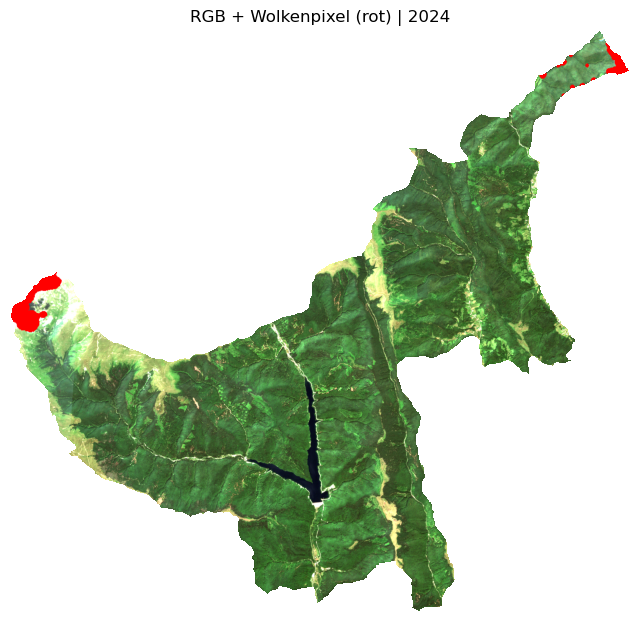

In [119]:
# RGB mit maskierten Pixeln in Rot plotten

rgb = processed_scenes[year]["rgb"]
cloud_pixels = processed_scenes[year]["cloud_pixels"].compute().values

rgb_check = rgb.copy()
rgb_check[cloud_pixels] = [1, 0, 0] 

plt.figure(figsize=(8, 8))
plt.imshow(rgb_check)
plt.axis("off")
plt.title(f"RGB + Wolkenpixel (rot) | {year}")
plt.show()

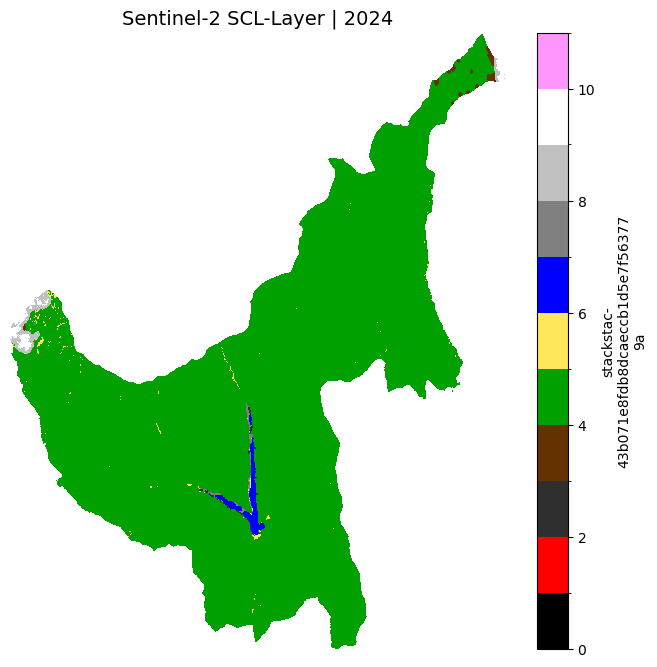

In [120]:
# SCL-Layer für gewähltes Jahr plotten

scl_layer = processed_scenes[year]["stack_scl"].sel(band="SCL")

# Daten laden
scl_layer = scl_layer.compute()

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

scl_layer.plot.imshow(
    ax=ax,
    cmap=cmap,
    norm=norm
)

ax.set_title(f"Sentinel-2 SCL-Layer | {year}", fontsize=14)
ax.set_axis_off()

plt.show()

### NDVI-Composite erstellen

In [121]:
year = years[0]

print(processed_scenes[year]["date"])

2021-07-29


In [122]:
print(processed_scenes[year].keys())

dict_keys(['date', 'stack_bands', 'stack_scl', 'stack_bands_masked', 'cloud_mask', 'cloud_pixels', 'cloud_fraction', 'n_tiles', 'rgb'])


In [123]:
test_bands = processed_scenes[year]["stack_bands_masked"]

In [124]:
red = test_bands.sel(band="B04").compute()
nir = test_bands.sel(band="B08").compute()

# NDVI berechnen mit Schutz vor Division durch 0 --> wenn NIR + RED = 0, dann Pixel = nan
# "wenn nir + red nicht null sind, dann (nir - red) / (nir + red), sonst nan"

ndvi = xr.where((nir + red) != 0, (nir - red) / (nir + red), np.nan)

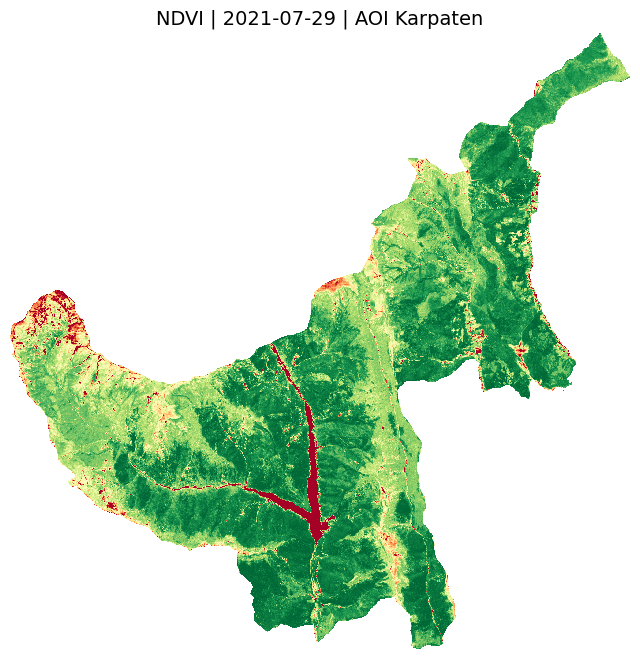

In [125]:
# Farbskala definieren
color_scale = "RdYlGn"

# Figure (gesamtes Bild) + Axes (Plotfläche)
fig, ax = plt.subplots(figsize=(8, 8))

# NDVI plotten mit Rot --> Grün Farbskala & Penzentil-Stretch (für besseren Kontrast)
ndvi.plot.imshow(
    ax=ax,
    cmap = color_scale,                      # Farbskala
    add_colorbar=False,                      # keine Farblegende
    vmin=np.nanpercentile(ndvi, 2),          # unterer Farbwert: 2%-Perzentil
    vmax=np.nanpercentile(ndvi, 98)          # oberer Farbwert: 98%-Perzentil
)

# Titel setzen
ax.set_title(f"NDVI | {processed_scenes[year]['date']} | AOI {aoi_name}", fontsize=14)

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

# Plot anzeigen
plt.show()

#### Loop über alle Jahre

- Einerseits Loop zur Berechnung der NDVI-Raster und zur Erstellung und Speicherung der Plots
- Andererseits hier direkt die NDVI-Raster in korrektes CRS bringen (sicherstellen) und als GeoTIFF abspeichern, um in einem anderen Skript damit weiterarbeiten zu können.

In [126]:
for year, data in processed_scenes.items():

    print(f"Processing NDVI {year}")

    stack = data["stack_bands_masked"]

    # Bänder auswählen
    red = stack.sel(band="B04").compute()
    nir = stack.sel(band="B08").compute()

    # NDVI berechnen
    ndvi = xr.where((nir + red) != 0, (nir - red) / (nir + red), np.nan)

    # NDVI in processed_scenes speichern
    processed_scenes[year]["ndvi"] = ndvi

    # CRS sicherstellen
    ndvi = ndvi.rio.write_crs(f"EPSG:{epsg}")

    # NDVI-Raster speichern (im Ordner Composites_GeoTIFF)
    ndvi.rio.to_raster(f"Composites_GeoTIFF/NDVI_{year}.tif")
    print(f"Saved NDVI_{year} as GeoTIFF")

    # Percentile berechnen
    vmin = np.nanpercentile(ndvi, 2)
    vmax = np.nanpercentile(ndvi, 98)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 8))

    ndvi.plot.imshow(
        ax=ax,
        cmap="RdYlGn",
        add_colorbar=False,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"NDVI | {data['date']} | AOI {aoi_name}", fontsize=14)
    ax.set_axis_off()

    # Speichern
    plt.savefig(f"Composites_Plots/NDVI_{year}.png", dpi=300, bbox_inches="tight")

    plt.close()

    print(f"Saved NDVI_{year} as PNG")
    print("-" * 35) # als Abgrenzung zur nächsten Iteration

Processing NDVI 2021
Saved NDVI_2021 as GeoTIFF
Saved NDVI_2021 as PNG
-----------------------------------
Processing NDVI 2022
Saved NDVI_2022 as GeoTIFF
Saved NDVI_2022 as PNG
-----------------------------------
Processing NDVI 2023
Saved NDVI_2023 as GeoTIFF
Saved NDVI_2023 as PNG
-----------------------------------
Processing NDVI 2024
Saved NDVI_2024 as GeoTIFF
Saved NDVI_2024 as PNG
-----------------------------------
Processing NDVI 2025
Saved NDVI_2025 as GeoTIFF
Saved NDVI_2025 as PNG
-----------------------------------


### NBR-Composite erstellen

In [127]:
year = years[0]

print(processed_scenes[year]["date"])

2021-07-29


In [128]:
test_bands = processed_scenes[year]["stack_bands_masked"]

In [129]:
nir = test_bands.sel(band="B08").compute()
swir = test_bands.sel(band="B12").compute()

# NBR berechnen mit Schutz vor Division durch 0 --> wenn NIR + SWIR = 0, dann Pixel = nan
# "wenn nir + swir nicht null sind, dann (nir - swir) / (nir + swir), sonst nan"
nbr = xr.where((nir + swir) != 0, (nir - swir) / (nir + swir), np.nan)

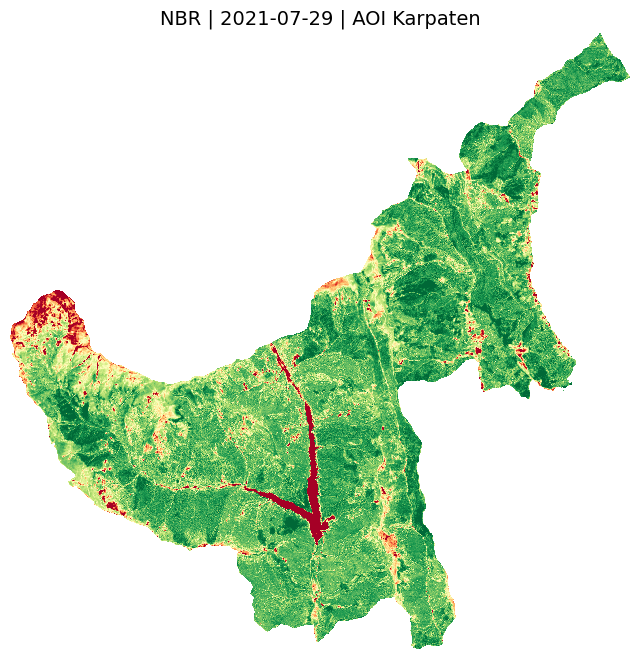

In [130]:
# Farbskala definieren
color_scale = "RdYlGn"

# Figure (gesamtes Bild) + Axes (Plotfläche)
fig, ax = plt.subplots(figsize=(8, 8))

# NBR plotten mit Rot --> Grün Farbskala & Penzentil-Stretch (für besseren Kontrast)
nbr.plot.imshow(
    ax=ax,
    cmap = color_scale,                     # Farbskala
    add_colorbar=False,                     # keine Farblegende
    vmin=np.nanpercentile(nbr, 2),          # unterer Farbwert: 2%-Perzentil
    vmax=np.nanpercentile(nbr, 98)          # oberer Farbwert: 98%-Perzentil
)

# Titel setzen
ax.set_title(f"NBR | {processed_scenes[year]['date']} | AOI {aoi_name}", fontsize=14)

# Achsen ausblenden für saubere Darstellung
ax.set_axis_off()

# Plot anzeigen
plt.show()

#### Loop über alle Jahre

In [131]:
for year, data in processed_scenes.items():

    print(f"Processing NBR {year}")

    stack = data["stack_bands_masked"]

    # Bänder auswählen
    nir = stack.sel(band="B08").compute()
    swir = stack.sel(band="B12").compute()

    # NBR berechnen
    nbr = xr.where((nir + swir) != 0, (nir - swir) / (nir + swir), np.nan)

    # NBR in processed_scenes speichern
    processed_scenes[year]["nbr"] = nbr

    # CRS sicherstellen
    nbr = nbr.rio.write_crs(f"EPSG:{epsg}")

    # NBR-Raster speichern (im Ordner Composites_GeoTIFF)
    nbr.rio.to_raster(f"Composites_GeoTIFF/NBR_{year}.tif")
    print(f"Saved NBR{year} as GeoTIFF")

    # Percentile berechnen
    vmin = np.nanpercentile(nbr, 2)
    vmax = np.nanpercentile(nbr, 98)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 8))

    nbr.plot.imshow(
        ax=ax,
        cmap="RdYlGn",
        add_colorbar=False,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"NBR | {data['date']} | AOI {aoi_name}", fontsize=14)
    ax.set_axis_off()

    # Speichern
    plt.savefig(f"Composites_Plots/NBR_{year}.png", dpi=300, bbox_inches="tight")

    plt.close()

    print(f"Saved NBR_{year} as PNG")
    print("-" * 35) # als Abgrenzung zur nächsten Iteration

Processing NBR 2021
Saved NBR2021 as GeoTIFF
Saved NBR_2021 as PNG
-----------------------------------
Processing NBR 2022
Saved NBR2022 as GeoTIFF
Saved NBR_2022 as PNG
-----------------------------------
Processing NBR 2023
Saved NBR2023 as GeoTIFF
Saved NBR_2023 as PNG
-----------------------------------
Processing NBR 2024
Saved NBR2024 as GeoTIFF
Saved NBR_2024 as PNG
-----------------------------------
Processing NBR 2025
Saved NBR2025 as GeoTIFF
Saved NBR_2025 as PNG
-----------------------------------


## Kernel neu starten

Da ich in einem anderen Skript mit den gespeicherten `.tif` und `.png` weiterarbeiten und diese überschreiben will, wird hier der Kernel neu gestartet, sodass die Dateien nicht vor Überschreibung blockiert werden.

In [ ]:
plt.close("all")

os._exit(0)